# I --- IMPORT AND CLEANING DATA

### 1. Load the data

In [3]:
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree



pd.set_option("display.max_columns", 60)

text_cols = ["LocationID", "BorrZip", "BankZip", "BankFDICNumber", "BankNCUANumber",
             "NaicsCode", "FranchiseCode", "CongressionalDistrict"]
raw = pd.read_csv("OG_FY2015-2019_SmallBusinessLoan.csv", dtype={c: str for c in text_cols}, low_memory=False)
raw.head()

,AsOfDate,Program,LocationID,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,BankName,BankFDICNumber,BankNCUANumber,BankStreet,BankCity,BankState,BankZip,GrossApproval,SBAGuaranteedApproval,ApprovalDate,ApprovalFY,FirstDisbursementDate,ProcessingMethod,InitialInterestRate,FixedorVariableInterestInd,TermInMonths,NaicsCode,NaicsDescription,FranchiseCode,FranchiseName,ProjectCounty,ProjectState,SBADistrictOffice,CongressionalDistrict,BusinessType,BusinessAge,LoanStatus,PaidInFullDate,ChargeOffDate,GrossChargeOffAmount,RevolverStatus,JobsSupported,CollateralInd,SoldSecMrktInd
0,2026-06-30,7A,0072188,Square Burger LLC,115 Kentucky Street,McKinney,TX,75069,American Bank of Commerce,18609,NaN,530 E Hwy 62/82,Wolfforth,TX,79382,288000.0,259200.0,2009-10-01,2010,2009-10-01,Preferred Lenders Program,6.00,V,120.0,722110,Full-Service Restaurants,NaN,NaN,COLLIN,TX,DALLAS / FT WORTH DISTRICT OFFICE,03,CORPORATION,Unanswered,P I F,2014-07-31,NaN,0.0,N,18.0,Y,NaN
1,2026-06-30,7A,0455644,Dr. Jeffrey Bacia and Dr. Louis Sardenga DBA P...,2608 Powers Drive,Orlando,FL,32818,Live Oak Banking Company,58665,NaN,1741 Tiburon Dr,WILMINGTON,NC,28403,1200000.0,1080000.0,2009-10-01,2010,2009-11-01,Preferred Lenders Program,4.75,V,300.0,541940,Veterinary Services,NaN,NaN,ORANGE,FL,NORTH FLORIDA DISTRICT OFFICE,10,PARTNERSHIP,"Existing, 5 or more years",P I F,2017-02-28,NaN,0.0,N,10.0,N,Y
2,2026-06-30,7A,0057328,Rocking Rodneys Ice House LLC,285 McReynolds Ranch Rd.,Burnet,TX,78611,The Huntington National Bank,06560,NaN,17 S High St.,COLUMBUS,OH,43215,120000.0,108000.0,2009-10-01,2010,2009-10-01,Preferred Lenders Program,5.25,V,90.0,312113,Ice Manufacturing,NaN,NaN,BURNET,TX,SAN ANTONIO DISTRICT OFFICE,25,CORPORATION,Less than 4 years old but at least 3,P I F,2012-05-31,NaN,0.0,N,4.0,N,NaN
3,2026-06-30,7A,0057328,Rfl Enterprises Of Michigan Inc,41920 Hayes Rd.,CLINTON TOWNSHIP,MI,48038,The Huntington National Bank,06560,NaN,17 S High St.,COLUMBUS,OH,43215,150000.0,75000.0,2009-10-01,2010,2010-04-01,SBA Express Program,5.25,V,60.0,722211,Limited-Service Restaurants,48400,LITTLE CEASAR'S PIZZA,MACOMB,MI,MICHIGAN DISTRICT OFFICE,09,CORPORATION,"Startup, Loan Funds will Open Business",P I F,2014-12-31,NaN,0.0,N,48.0,Y,NaN
4,2026-06-30,7A,0436696,IL Entity to be established,615 N. Cedar,Shelbyville,IL,62565,OakStar Bank,58115,NaN,1020 E Battlefield Rd,SPRINGFIELD,MO,65807,790000.0,711000.0,2009-10-01,2010,NaN,Preferred Lenders Program,6.00,V,240.0,447110,Gasoline Stations with Convenience Stores,NaN,NaN,SHELBY,IL,ILLINOIS DISTRICT OFFICE,15,CORPORATION,"New, Less than 1 Year old",CANCLD,NaN,NaN,0.0,N,0.0,Y,NaN


### 2. Keep FY2015–2019 only
The downloaded file covers **FY2010–FY2019** (545,751 loans) even though it's named FY2015–2019, so we filter on the approval fiscal year.
The SBA fiscal year runs Oct 1 – Sep 30, so FY2015 = Oct 2014 to Sep 2015.

In [5]:
print(raw["ApprovalFY"].value_counts().sort_index())
df = raw[raw["ApprovalFY"].between(2015, 2019)].copy()
print("Kept:", df.shape)

# Exact duplicate rows (every one of the 42 columns identical, including borrower address).
# The file has no loan ID, so these are treated as double entries. Most are Cancelled / Paid in Full.
dups = df.duplicated()
print("Exact duplicates removed:", dups.sum())
df = df[~dups].reset_index(drop=True)

ApprovalFY
2010    47000
2011    53710
2012    44376
2013    46395
2014    52044
2015    63461
2016    64074
2017    62430
2018    60354
2019    51907
Name: count, dtype: int64
Kept: (302226, 42)
Exact duplicates removed: 337


### 3. Drop columns we don't need
| Column | Why drop |
|---|---|
| AsOfDate, Program | Same value on every row (2026-06-30, "7A") |
| BorrStreet, BankStreet | Street addresses. City/state/ZIP are enough for analysis |
| LocationID | Internal SBA location code, not useful for analysis |
| FranchiseCode | Replaced by a simple Yes/No franchise flag (name is kept) |

In [7]:
print(df[["AsOfDate", "Program"]].nunique())
df["is_franchise"] = np.where(df["FranchiseCode"].notna(), "Yes", "No")
df = df.drop(columns=["AsOfDate", "Program", "BorrStreet", "BankStreet", "LocationID", "FranchiseCode"])

AsOfDate    1
Program     1
dtype: int64


### 4. Rename columns to readable names

In [9]:
rename_map = {
    "BorrName": "borrower_name",
    "BorrCity": "borrower_city",
    "BorrState": "borrower_state",
    "BorrZip": "borrower_zip",
    "BankName": "lender_name_raw",
    "BankFDICNumber": "lender_fdic_cert",
    "BankNCUANumber": "lender_ncua_charter",
    "BankCity": "lender_city",
    "BankState": "lender_state",
    "BankZip": "lender_zip",
    "GrossApproval": "loan_amount",
    "SBAGuaranteedApproval": "sba_guaranteed_amount",
    "ApprovalDate": "approval_date",
    "ApprovalFY": "approval_fiscal_year",
    "FirstDisbursementDate": "first_disbursement_date",
    "ProcessingMethod": "loan_program",
    "InitialInterestRate": "interest_rate_pct",
    "FixedorVariableInterestInd": "interest_rate_type",
    "TermInMonths": "term_months",
    "NaicsCode": "naics_code",
    "NaicsDescription": "industry",
    "FranchiseName": "franchise_name",
    "ProjectCounty": "project_county",
    "ProjectState": "project_state",
    "SBADistrictOffice": "sba_district_office",
    "CongressionalDistrict": "congressional_district",
    "BusinessType": "business_type",
    "BusinessAge": "business_age_raw",
    "LoanStatus": "loan_status",
    "PaidInFullDate": "paid_in_full_date",
    "ChargeOffDate": "charge_off_date",
    "GrossChargeOffAmount": "charge_off_amount",
    "RevolverStatus": "is_revolving_line",
    "JobsSupported": "jobs_supported",
    "CollateralInd": "has_collateral",
    "SoldSecMrktInd": "sold_on_secondary_market",
}
df = df.rename(columns=rename_map)
df.columns.tolist()

['borrower_name',
 'borrower_city',
 'borrower_state',
 'borrower_zip',
 'lender_name_raw',
 'lender_fdic_cert',
 'lender_ncua_charter',
 'lender_city',
 'lender_state',
 'lender_zip',
 'loan_amount',
 'sba_guaranteed_amount',
 'approval_date',
 'approval_fiscal_year',
 'first_disbursement_date',
 'loan_program',
 'interest_rate_pct',
 'interest_rate_type',
 'term_months',
 'naics_code',
 'industry',
 'franchise_name',
 'project_county',
 'project_state',
 'sba_district_office',
 'congressional_district',
 'business_type',
 'business_age_raw',
 'loan_status',
 'paid_in_full_date',
 'charge_off_date',
 'charge_off_amount',
 'is_revolving_line',
 'jobs_supported',
 'has_collateral',
 'sold_on_secondary_market',
 'is_franchise']

## 5. Decode abbreviations into plain English
Meanings come from the SBA FOIA data dictionary.

| Raw code | Meaning |
|---|---|
| `P I F` | Paid in Full |
| `CHGOFF` | Charged Off (the loan defaulted and the remaining balance was written off) |
| `CANCLD` | Cancelled (approved but never disbursed) |
| `EXEMPT` | Active, status undisclosed (disbursed but not paid off or charged off; SBA withholds the status) |
| `COMMIT` | Committed, not yet disbursed |
| `F` / `V` | Fixed / Variable interest rate |
| `Y` / `N` | Yes / No |

In [11]:
df["loan_status"] = df["loan_status"].str.strip().map({
    "P I F": "Paid in Full",
    "CHGOFF": "Charged Off",
    "CANCLD": "Cancelled",
    "EXEMPT": "Active (Undisclosed)",
    "COMMIT": "Committed (Not Disbursed)",
})
df["interest_rate_type"] = df["interest_rate_type"].map({"F": "Fixed", "V": "Variable"})

yn = {"Y": "Yes", "N": "No"}
df["is_revolving_line"] = df["is_revolving_line"].map(yn)
df["has_collateral"] = df["has_collateral"].map(yn)
df["sold_on_secondary_market"] = df["sold_on_secondary_market"].map(yn).fillna("Not Reported")

df["business_type"] = df["business_type"].str.strip().str.title().fillna("Unknown")

for c in ["loan_status", "interest_rate_type", "is_revolving_line", "has_collateral"]:
    print(df[c].value_counts(dropna=False), "\n")

loan_status
Paid in Full                 204911
Active (Undisclosed)          43565
Cancelled                     33836
Charged Off                   19533
Committed (Not Disbursed)        44
Name: count, dtype: int64 

interest_rate_type
Variable    235787
Fixed        66102
Name: count, dtype: int64 

is_revolving_line
No     207967
Yes     93922
Name: count, dtype: int64 

has_collateral
Yes    218647
No      83242
Name: count, dtype: int64 



### Business age: combine overlapping labels
SBA changed its form over time, so there are 10 overlapping labels. Group them into 6 clear categories.

In [13]:
business_age_map = {
    "Startup, Loan Funds will Open Business": "Startup (not yet open)",
    "New, Less than 1 Year old": "New (under 2 years)",
    "New Business or 2 years or less": "New (under 2 years)",
    "Less than 3 years old but at least 2": "Established (2-5 years)",
    "Less than 4 years old but at least 3": "Established (2-5 years)",
    "Less than 5 years old but at least 4": "Established (2-5 years)",
    "Existing or more than 2 years old": "Established (2+ years, exact age unknown)",
    "Existing, 5 or more years": "Mature (5+ years)",
    "Change of Ownership": "Change of Ownership",
    "Unanswered": "Unknown",
}
df["business_age"] = df["business_age_raw"].map(business_age_map).fillna("Unknown")
df = df.drop(columns="business_age_raw")
df["business_age"].value_counts()

business_age
Mature (5+ years)                            95587
Established (2+ years, exact age unknown)    51820
Startup (not yet open)                       48247
Established (2-5 years)                      34449
Unknown                                      32385
New (under 2 years)                          29017
Change of Ownership                          10384
Name: count, dtype: int64

### Loan program: add a simpler grouping
18 program names → 6 groups (keep the detailed `loan_program` column too).

In [15]:
def program_group(p):
    if "Express" in p and "Export" not in p:
        return "SBA Express"
    if "Preferred Lenders" in p:
        return "Preferred Lender (PLP)"
    if "CAPLine" in p:
        return "Working Capital Line (CAPLine)"
    if "EWCP" in p or "Export" in p or "International Trade" in p:
        return "Export / International Trade"
    if "Community Advantage" in p or "Small Loan Advantage" in p or "Rural" in p:
        return "Special Initiatives"
    return "Standard 7(a)"

df["loan_program_group"] = df["loan_program"].apply(program_group)
pd.crosstab(df["loan_program"], df["loan_program_group"]).T

loan_program,7a General,7a with EWCP,Builders CAPLine,Certified Lenders Program,Certified Lenders Program with EWCP,Community Advantage Initiative,Community Advantage International Trade,Contract CAPLine,Export Express,International Trade Loans,Preferred Lenders Program,Preferred Lenders with EWCP,Rural Loan Initiative,SBA Express Bridge Loan,SBA Express Program,Seasonal CAPLine,Small Loan Advantage Initiative,Working Capital CAPLine
loan_program_group,,,,,,,,,,,,,,,,,,
Export / International Trade,0,461,0,0,3,0,5,0,418,1091,0,0,0,0,0,0,0,0
Preferred Lender (PLP),0,0,0,0,0,0,0,0,0,0,108996,355,0,0,0,0,0,0
SBA Express,0,0,0,0,0,0,0,0,0,0,0,0,0,2,144747,0,0,0
Special Initiatives,0,0,0,0,0,4922,0,0,0,0,0,0,11,0,0,0,18985,0
Standard 7(a),18803,0,0,928,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Working Capital Line (CAPLine),0,0,84,0,0,0,0,281,0,0,0,0,0,0,0,127,0,1670


### 6. Fix data types: dates, numbers, ZIP codes

In [17]:
for c in ["approval_date", "first_disbursement_date", "paid_in_full_date", "charge_off_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df["borrower_zip"] = df["borrower_zip"].str.zfill(5)
df["lender_zip"] = df["lender_zip"].str.zfill(5)
df["naics_code"] = df["naics_code"].str.replace(r"\.0$", "", regex=True)
df["congressional_district"] = df["congressional_district"].str.replace(r"\.0$", "", regex=True)
for c in ["lender_fdic_cert", "lender_ncua_charter"]:
    df[c] = df[c].str.replace(r"\.0$", "", regex=True).str.lstrip("0")

df["jobs_supported"] = df["jobs_supported"].astype("Int64")
df.dtypes

borrower_name                       object
borrower_city                       object
borrower_state                      object
borrower_zip                        object
lender_name_raw                     object
lender_fdic_cert                    object
lender_ncua_charter                 object
lender_city                         object
lender_state                        object
lender_zip                          object
loan_amount                        float64
sba_guaranteed_amount              float64
approval_date               datetime64[ns]
approval_fiscal_year                 int64
first_disbursement_date     datetime64[ns]
loan_program                        object
interest_rate_pct                  float64
interest_rate_type                  object
term_months                        float64
naics_code                          object
industry                            object
franchise_name                      object
project_county                      object
project_sta

### 7. Data quality fixes
Each issue below was found while profiling the data. We count it, fix it, and record why.

In [19]:
# (Exact duplicates were already removed in step 2.)

# 7a. Loan term of 0 months is impossible, and over 360 months (30 years) is beyond 7(a) limits -> set to missing
bad_term = (df["term_months"] <= 0) | (df["term_months"] > 360)
print("Invalid terms set to NaN:", bad_term.sum())
df.loc[bad_term, "term_months"] = np.nan

# 7b. Interest rate of 0% is not a real 7(a) rate -> set to missing
bad_rate = df["interest_rate_pct"] <= 0
print("0% interest rates set to NaN:", bad_rate.sum())
df.loc[bad_rate, "interest_rate_pct"] = np.nan

# 7c. Missing text fields -> 'Unknown' so they show up as a group in Tableau instead of disappearing
df["industry"] = df["industry"].str.strip().fillna("Unknown")
df["borrower_name"] = df["borrower_name"].fillna("Unknown")

# 7d. Tidy text: trim spaces, consistent capitalization
for c in ["borrower_city", "lender_city", "project_county", "sba_district_office"]:
    df[c] = df[c].str.strip().str.title()

Invalid terms set to NaN: 118
0% interest rates set to NaN: 8


### 8. Lender identity (entity resolution)
**Finding:** SBA already spells each lender one consistent way, but the reverse problem exists:
**86 names are shared by different lenders** (e.g. two unrelated "First Financial Bank"s with different FDIC numbers).
If you group by name alone in Python or Tableau, you'll merge separate banks.

**Fix:**
- `lender_id`: a unique ID per lender, using the FDIC certificate number, else the NCUA charter number, else the name.
- `lender_name`: a display name. Shared names get the lender's city and state added, e.g. *First Financial Bank (El Dorado, AR)* vs *First Financial Bank (Cincinnati, OH)*.

In [21]:
df["lender_name_raw"] = df["lender_name_raw"].str.strip()

df["lender_id"] = np.select(
    [df["lender_fdic_cert"].notna(), df["lender_ncua_charter"].notna()],
    ["FDIC-" + df["lender_fdic_cert"].astype(str), "NCUA-" + df["lender_ncua_charter"].astype(str)],
    default="NAME-" + df["lender_name_raw"].fillna("Unknown"))

ids_per_name = df.groupby("lender_name_raw")["lender_id"].nunique()
shared_names = ids_per_name[ids_per_name > 1].index
print("Names shared by 2+ different lenders:", len(shared_names))

# city/state for each lender = its most common location in the data
lender_loc = (df.groupby("lender_id")[["lender_city", "lender_state"]]
                .agg(lambda s: s.mode().iat[0] if s.notna().any() else ""))
loc_label = df["lender_id"].map(lender_loc["lender_city"] + ", " + lender_loc["lender_state"])

df["lender_name"] = np.where(df["lender_name_raw"].isin(shared_names),
                             df["lender_name_raw"] + " (" + loc_label + ")",
                             df["lender_name_raw"])
df["lender_name"] = df["lender_name"].fillna("Unknown")

print("Unique raw names:   ", df["lender_name_raw"].nunique())
print("Unique lender IDs:  ", df["lender_id"].nunique())
print("Unique display names:", df["lender_name"].nunique())
df.loc[df["lender_name_raw"] == "First Financial Bank", ["lender_id", "lender_name"]].value_counts()

Names shared by 2+ different lenders: 86
Unique raw names:    2170
Unique lender IDs:   2326
Unique display names: 2326


lender_id   lender_name                          
FDIC-28905  First Financial Bank (El Dorado, AR)     1164
FDIC-6600   First Financial Bank (Cincinnati, OH)     688
FDIC-3066   First Financial Bank (Abilene, TX)        127
Name: count, dtype: int64

### 9. Helper columns for analysis and Tableau

In [23]:
# Lender type: FDIC-insured bank, credit union (NCUA), or non-bank lender (neither ID)
df["lender_type"] = np.select(
    [df["lender_fdic_cert"].notna(), df["lender_ncua_charter"].notna()],
    ["Bank", "Credit Union"], default="Non-Bank Lender")

# Is the lender based in a different state than the borrower?
df["out_of_state_lender"] = np.where(df["lender_state"] != df["borrower_state"], "Yes", "No")

# Loan structure
df["sba_guarantee_pct"] = (df["sba_guaranteed_amount"] / df["loan_amount"] * 100).round(1)
df["term_years"] = (df["term_months"] / 12).round(1)
df["loan_size_band"] = pd.cut(df["loan_amount"],
    bins=[0, 50_000, 150_000, 350_000, 1_000_000, 5_000_001],
    labels=["Under $50K", "$50K-150K", "$150K-350K", "$350K-1M", "$1M-5M"], right=False)
df["term_band"] = pd.cut(df["term_months"], bins=[0, 60, 120, 240, 361],
    labels=["Up to 5 yrs", "5-10 yrs", "10-20 yrs", "20+ yrs"], right=False)

# Industry sector from the first 2 digits of the NAICS code
naics_sectors = {
    "11": "Agriculture, Forestry & Fishing", "21": "Mining, Oil & Gas", "22": "Utilities",
    "23": "Construction", "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "42": "Wholesale Trade", "44": "Retail Trade", "45": "Retail Trade",
    "48": "Transportation & Warehousing", "49": "Transportation & Warehousing",
    "51": "Information", "52": "Finance & Insurance", "53": "Real Estate & Rental",
    "54": "Professional, Scientific & Technical", "55": "Management of Companies",
    "56": "Administrative & Waste Services", "61": "Educational Services",
    "62": "Health Care & Social Assistance", "71": "Arts, Entertainment & Recreation",
    "72": "Accommodation & Food Services", "81": "Other Services", "92": "Public Administration",
}
df["industry_sector"] = df["naics_code"].str[:2].map(naics_sectors).fillna("Unknown")

# U.S. Census region of the project (territories grouped separately)
regions = {
    "Northeast": ["CT", "ME", "MA", "NH", "RI", "VT", "NJ", "NY", "PA"],
    "Midwest": ["IL", "IN", "MI", "OH", "WI", "IA", "KS", "MN", "MO", "NE", "ND", "SD"],
    "South": ["DE", "DC", "FL", "GA", "MD", "NC", "SC", "VA", "WV", "AL", "KY", "MS", "TN",
              "AR", "LA", "OK", "TX"],
    "West": ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY", "AK", "CA", "HI", "OR", "WA"],
}
state_region = {s: r for r, states in regions.items() for s in states}
df["region"] = df["project_state"].map(state_region).fillna("U.S. Territories")

### The target: did the loan default?
Only **Paid in Full** and **Charged Off** loans have a known final outcome.
Cancelled, Active and Committed loans get `NaN` so they're excluded when calculating default rates.

In [25]:
df["outcome_known"] = df["loan_status"].isin(["Paid in Full", "Charged Off"])
df["charged_off"] = np.where(df["loan_status"] == "Charged Off", 1,
                     np.where(df["loan_status"] == "Paid in Full", 0, np.nan))

co = df["loan_status"] == "Charged Off"
df["charge_off_pct_of_loan"] = np.where(co, (df["charge_off_amount"] / df["loan_amount"] * 100).round(1), np.nan)
df["months_to_charge_off"] = np.where(co,
    ((df["charge_off_date"] - df["approval_date"]).dt.days / 30.44).round(0), np.nan)

df[["loan_status", "outcome_known", "charged_off"]].value_counts(dropna=False)

loan_status                outcome_known  charged_off
Paid in Full               True           0.0            204911
Active (Undisclosed)       False          NaN             43565
Cancelled                  False          NaN             33836
Charged Off                True           1.0             19533
Committed (Not Disbursed)  False          NaN                44
Name: count, dtype: int64

### 10. Validation checks

In [27]:
assert df["approval_fiscal_year"].between(2015, 2019).all()
assert (df["sba_guaranteed_amount"] <= df["loan_amount"]).all(), "guarantee larger than loan"
assert df["loan_status"].notna().all(), "unmapped loan status"
assert (df.loc[df["loan_status"] != "Charged Off", "charge_off_amount"] == 0).all()
assert df["borrower_zip"].str.len().eq(5).all()
print("All checks passed")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Default rate (loans with a known outcome): {df['charged_off'].mean():.1%}")

All checks passed
Rows: 301,889 | Columns: 52
Default rate (loans with a known outcome): 8.7%


### 11. Reorder columns and save

In [29]:
col_order = [
    # loan
    "approval_date", "approval_fiscal_year", "first_disbursement_date", "loan_program", "loan_program_group",
    "loan_amount", "sba_guaranteed_amount", "sba_guarantee_pct", "loan_size_band",
    "interest_rate_pct", "interest_rate_type", "term_months", "term_years", "term_band",
    "is_revolving_line", "has_collateral", "sold_on_secondary_market", "jobs_supported",
    # outcome
    "loan_status", "outcome_known", "charged_off", "paid_in_full_date", "charge_off_date",
    "charge_off_amount", "charge_off_pct_of_loan", "months_to_charge_off",
    # borrower
    "borrower_name", "business_type", "business_age", "naics_code", "industry", "industry_sector",
    "is_franchise", "franchise_name", "borrower_city", "borrower_state", "borrower_zip",
    "project_county", "project_state", "region", "sba_district_office", "congressional_district",
    # lender
    "lender_id", "lender_name", "lender_name_raw", "lender_type", "lender_fdic_cert", "lender_ncua_charter",
    "lender_city", "lender_state", "lender_zip", "out_of_state_lender",
]
assert set(col_order) == set(df.columns), set(df.columns) ^ set(col_order)
df = df[col_order]
df.to_csv("sba_loans_clean.csv", index=False)
print("Saved sba_loans_clean.csv", df.shape)
df.head()

Saved sba_loans_clean.csv (301889, 52)


,approval_date,approval_fiscal_year,first_disbursement_date,loan_program,loan_program_group,loan_amount,sba_guaranteed_amount,sba_guarantee_pct,loan_size_band,interest_rate_pct,interest_rate_type,term_months,term_years,term_band,is_revolving_line,has_collateral,sold_on_secondary_market,jobs_supported,loan_status,outcome_known,charged_off,paid_in_full_date,charge_off_date,charge_off_amount,charge_off_pct_of_loan,months_to_charge_off,borrower_name,business_type,business_age,naics_code,industry,industry_sector,is_franchise,franchise_name,borrower_city,borrower_state,borrower_zip,project_county,project_state,region,sba_district_office,congressional_district,lender_id,lender_name,lender_name_raw,lender_type,lender_fdic_cert,lender_ncua_charter,lender_city,lender_state,lender_zip,out_of_state_lender
0,2014-10-01,2015,2014-12-01,Community Advantage Initiative,Special Initiatives,150000.0,127500.0,85.0,$150K-350K,8.25,Variable,32.0,2.7,Up to 5 yrs,No,Yes,Yes,5,Charged Off,True,1.0,NaT,2019-08-23,75072.57,50.0,59.0,MGC Paint Supplies Corp.,Corporation,Mature (5+ years),441310,Automotive Parts and Accessories Stores,Retail Trade,No,NaN,Deer Park,NY,11729,Suffolk,NY,Northeast,New York District Office,02,NAME-Empire State Certified Development Corpor...,Empire State Certified Development Corporation,Empire State Certified Development Corporation,Non-Bank Lender,NaN,NaN,Latham,NY,12110,No
1,2014-10-01,2015,2015-01-01,Small Loan Advantage Initiative,Special Initiatives,300000.0,225000.0,75.0,$150K-350K,6.00,Variable,240.0,20.0,20+ yrs,No,Yes,Not Reported,3,Active (Undisclosed),False,NaN,NaT,NaT,0.00,NaN,NaN,"Pay Dirt, Inc.",Corporation,Startup (not yet open),453310,Used Merchandise Stores,Retail Trade,Yes,PLATO'S CLOSET,Woodbridge,VA,22193,Prince William,VA,South,Richmond District Office,01,NCUA-5500,Northwest FCU,Northwest FCU,Credit Union,NaN,5500,Herndon,VA,20170,No
2,2014-10-01,2015,2014-11-01,SBA Express Program,SBA Express,50000.0,25000.0,50.0,$50K-150K,8.50,Variable,84.0,7.0,5-10 yrs,Yes,No,Not Reported,0,Paid in Full,True,0.0,2019-01-31,NaT,0.00,NaN,NaN,SeaCap Advisors LLC,Corporation,Established (2-5 years),523930,Investment Advice,Finance & Insurance,No,NaN,Honolulu,HI,96816,Honolulu,HI,West,Hawaii District Office,01,FDIC-17308,Central Pacific Bank,Central Pacific Bank,Bank,17308,NaN,Honolulu,HI,96813,No
3,2014-10-01,2015,2014-10-01,SBA Express Program,SBA Express,25900.0,12950.0,50.0,Under $50K,4.09,Fixed,60.0,5.0,5-10 yrs,No,No,Not Reported,0,Paid in Full,True,0.0,2018-01-31,NaT,0.00,NaN,NaN,Samir Sljivo dba Samir Sljivo Trucking,Individual,Mature (5+ years),484121,"General Freight Trucking, Long-Distance, Truck...",Transportation & Warehousing,No,NaN,Kentwood,MI,49508,Kent,MI,Midwest,Michigan District Office,02,FDIC-6560,The Huntington National Bank,The Huntington National Bank,Bank,6560,NaN,Columbus,OH,43215,Yes
4,2014-10-01,2015,2015-02-01,Small Loan Advantage Initiative,Special Initiatives,106100.0,90185.0,85.0,$50K-150K,5.50,Fixed,72.0,6.0,5-10 yrs,No,Yes,Not Reported,1,Paid in Full,True,0.0,2016-09-30,NaT,0.00,NaN,NaN,"Carne Trucking, Inc",Corporation,Startup (not yet open),113310,Logging,"Agriculture, Forestry & Fishing",No,NaN,Iron River,MI,49935,Iron,MI,Midwest,Michigan District Office,01,FDIC-5062,First National Bank & Trust Co,First National Bank & Trust Co,Bank,5062,NaN,Iron Mountain,MI,49801,No


# II --- Data dictionary

### Loan details
- **approval_date**: Approval Date. The date SBA approved the loan.
- **approval_fiscal_year**: Approval Fiscal Year. SBA fiscal year of approval (runs Oct 1 to Sep 30, so FY2015 = Oct 2014 to Sep 2015).
- **first_disbursement_date**: First Disbursement Date. The date the borrower first received money. Blank if the loan was never paid out.
- **loan_program**: Loan Program. The detailed SBA program or processing method (e.g. SBA Express Program, Preferred Lenders Program).
- **loan_program_group** ★: Loan Program Group. The 18 programs grouped into 6 categories (SBA Express, Preferred Lender, Standard 7(a), Special Initiatives, Export / International Trade, Working Capital Line).
- **loan_amount**: Loan Amount. Total loan amount approved.
- **sba_guaranteed_amount**: SBA Guaranteed Amount. The portion SBA promises to repay the lender if the borrower defaults.
- **sba_guarantee_pct** ★: SBA Guarantee %. Guaranteed amount ÷ loan amount × 100.
- **loan_size_band** ★: Loan Size Band. Loan amount grouped as Under $50K, $50K-150K, $150K-350K, $350K-1M, or $1M-5M.
- **interest_rate_pct**: Interest Rate (%). Interest rate at approval.
- **interest_rate_type**: Interest Rate Type. Fixed or Variable.
- **term_months**: Loan Term (Months). Length of the loan in months.
- **term_years** ★: Loan Term (Years). Term in months ÷ 12.
- **term_band** ★: Term Band. Term grouped as Up to 5 yrs, 5-10 yrs, 10-20 yrs, or 20+ yrs.
- **is_revolving_line**: Revolving Line of Credit. Yes if the loan is a credit line the borrower can draw on and repay repeatedly, like a credit card.
- **has_collateral**: Has Collateral. Yes if the loan is backed by assets the lender can take if the borrower doesn't repay.
- **sold_on_secondary_market**: Sold on Secondary Market. Yes if the lender sold the SBA-guaranteed portion to investors. Not Reported if blank.
- **jobs_supported**: Jobs Supported. Number of jobs the borrower reported the loan would create or keep.

### Loan outcome
- **loan_status**: Loan Status. Paid in Full, Charged Off, Cancelled, Active (Undisclosed), or Committed (Not Disbursed).
- **outcome_known** ★: Outcome Known. True if the loan has a final result (Paid in Full or Charged Off).
- **charged_off** ★: Charged Off (Target). 1 = defaulted, 0 = paid in full, blank = outcome unknown. **Main variable for default-rate analysis.**
- **paid_in_full_date**: Paid in Full Date. The date the loan was fully repaid.
- **charge_off_date**: Charge-Off Date. The date the loan was written off as a loss.
- **charge_off_amount**: Charge-Off Amount. The amount written off (0 unless the loan was charged off).
- **charge_off_pct_of_loan** ★: Charge-Off % of Loan. Charge-off amount ÷ loan amount × 100 (charged-off loans only).
- **months_to_charge_off** ★: Months to Charge-Off. Months from approval to charge-off (charged-off loans only).

### Borrower (the small business)
- **borrower_name**: Borrower Name. Name of the business.
- **business_type**: Business Type. Corporation, Individual, or Partnership.
- **business_age**: Business Age. Startup (not yet open), New (under 2 years), Established (2-5 years), Established (2+ years, exact age unknown), Mature (5+ years), Change of Ownership, or Unknown.
- **naics_code**: NAICS Code. The 6-digit North American Industry Classification System (NAICS) code for the business's industry.
- **industry**: Industry. Plain-English description of the NAICS code (e.g. Full-Service Restaurants).
- **industry_sector** ★: Industry Sector. Broad sector from the first 2 digits of the NAICS code (e.g. Accommodation & Food Services).
- **is_franchise** ★: Is Franchise. Yes if the business is a franchise.
- **franchise_name**: Franchise Name. The franchise brand, if any.
- **borrower_city**: Borrower City. Where the business is located.
- **borrower_state**: Borrower State. Two-letter state code.
- **borrower_zip**: Borrower ZIP. 5-digit ZIP code.
- **project_county**: Project County. County where the loan money is used.
- **project_state**: Project State. State where the loan money is used. **Use this for maps.**
- **region** ★: Region. U.S. Census region of the project state (Northeast, Midwest, South, West, or U.S. Territories).
- **sba_district_office**: SBA District Office. The SBA office that oversees the loan.
- **congressional_district**: Congressional District. The borrower's congressional district number.

### Lender (the bank or institution)
- **lender_id** ★: Lender ID. Unique lender ID (FDIC number, else NCUA number, else name). **Use this to group by lender.**
- **lender_name** ★: Lender Name. Clean display name. Names shared by different lenders include city and state, e.g. First Financial Bank (Cincinnati, OH).
- **lender_name_raw**: Lender Name (Original). The name exactly as SBA reported it.
- **lender_type** ★: Lender Type. Bank (FDIC-insured), Credit Union (NCUA), or Non-Bank Lender.
- **lender_fdic_cert**: FDIC Certificate Number. The bank's unique FDIC ID. Blank for credit unions and non-banks.
- **lender_ncua_charter**: NCUA Charter Number. The credit union's unique National Credit Union Administration (NCUA) ID.
- **lender_city**: Lender City. Where the lender is headquartered.
- **lender_state**: Lender State. The lender's headquarters state.
- **lender_zip**: Lender ZIP. The lender's 5-digit ZIP code.
- **out_of_state_lender** ★: Out-of-State Lender. Yes if the lender's headquarters state differs from the borrower's state.

# III --- Analysis

## Question 1: Who defaults? Which industries, business ages and loan sizes charge off most?

### 1.1 Overall picture

In [35]:
STATUS_ORDER = ["Paid in Full", "Charged Off", "Active (Undisclosed)", "Cancelled / Not Disbursed"]
AGE_ORDER = ["Startup (not yet open)", "New (under 2 years)", "Established (2-5 years)",
             "Mature (5+ years)", "Established (2+ years, exact age unknown)",
             "Change of Ownership", "Unknown"]
band_order = ["Under $50K", "$50K-150K", "$150K-350K", "$350K-1M", "$1M-5M"]
region_order = ["Northeast", "Midwest", "South", "West", "U.S. Territories"]

# Cancelled and Committed both mean "money never lent", so they share one group
df["status_group"] = pd.Categorical(
    df["loan_status"].replace({"Cancelled": "Cancelled / Not Disbursed",
                               "Committed (Not Disbursed)": "Cancelled / Not Disbursed"}),
    categories=STATUS_ORDER)
df["business_age"] = pd.Categorical(df["business_age"], categories=AGE_ORDER)
df["loan_size_band"] = pd.Categorical(df["loan_size_band"], categories=band_order, ordered=True)
df["region"] = pd.Categorical(df["region"], categories=region_order, ordered=True)


class StatusReport:
    """Loan count, status mix %, default rate and loan amounts for any grouping.

    Status mix %   = loans in each status / all loans in the group (row adds to 100%)
    Default rate % = Charged Off / (Paid in Full + Charged Off)  -> the risk number to quote
    """

    def __init__(self, data, min_known=100):
        self.data = data
        self.min_known = min_known      # hide default rates built on too few finished loans

    @staticmethod
    def _cols(by):
        return [by] if isinstance(by, str) else list(by)

    def status_mix(self, by):
        by = self._cols(by)
        counts = pd.crosstab([self.data[c] for c in by], self.data["status_group"])
        counts = counts.reindex(columns=STATUS_ORDER, fill_value=0)
        out = counts.div(counts.sum(axis=1), axis=0).mul(100).add_suffix(" %")
        out.insert(0, "Loans", counts.sum(axis=1))
        out.insert(1, "% of all loans", out["Loans"] / len(self.data) * 100)
        finished = counts["Paid in Full"] + counts["Charged Off"]
        out["Known outcome"] = finished
        out["Default rate %"] = (counts["Charged Off"] / finished * 100).where(finished >= self.min_known)
        return out

    def amounts(self, by):
        return (self.data.groupby(self._cols(by), observed=True)["loan_amount"]
                    .agg(**{"Total lent ($M)": lambda s: s.sum() / 1e6,
                            "Median amount": "median", "Average amount": "mean"}))

    def amounts_by_status(self, by, stat="median"):
        return (self.data.pivot_table(index=self._cols(by), columns="status_group", values="loan_amount",
                                      aggfunc=stat, observed=True)
                    .reindex(columns=STATUS_ORDER))

    def summary(self, by):
        return self.status_mix(by).join(self.amounts(by))

    @staticmethod
    def style(table, highlight="Default rate %"):
        fmt = {}
        for c in table.columns:
            name = " ".join(map(str, c)) if isinstance(c, tuple) else str(c)
            if name in ("Loans", "Known outcome"):
                fmt[c] = "{:,.0f}"
            elif "%" in name:
                fmt[c] = "{:.1f}%"
            elif "($M)" in name:
                fmt[c] = "${:,.1f}M"
            else:
                fmt[c] = "${:,.0f}"
        styler = table.style.format(fmt, na_rep="–")
        if highlight in table.columns:
            styler = styler.background_gradient(cmap="Reds", subset=[highlight])
        return styler


report = StatusReport(df)

# Baseline for the whole portfolio
baseline = StatusReport(df.assign(portfolio="All loans")).summary("portfolio")
StatusReport.style(baseline)

,Loans,% of all loans,Paid in Full %,Charged Off %,Active (Undisclosed) %,Cancelled / Not Disbursed %,Known outcome,Default rate %,Total lent ($M),Median amount,Average amount
portfolio,,,,,,,,,,,
All loans,"301,889",100.0%,67.9%,6.5%,14.4%,11.2%,"224,444",8.7%,"$121,523.1M","$135,000","$402,542"


### 1.2 Industry sector by loan status
How did each sector's loans end up, and which sectors default most?

In [37]:
# Every sector: how its loans ended up, plus its default rate
sector_tbl = report.summary("industry_sector").sort_values("Default rate %", ascending=False)
StatusReport.style(sector_tbl)

,Loans,% of all loans,Paid in Full %,Charged Off %,Active (Undisclosed) %,Cancelled / Not Disbursed %,Known outcome,Default rate %,Total lent ($M),Median amount,Average amount
industry_sector,,,,,,,,,,,
"Arts, Entertainment & Recreation","10,280",3.4%,64.3%,8.5%,15.3%,11.9%,"7,486",11.6%,"$4,522.7M","$151,850","$439,953"
Transportation & Warehousing,"18,111",6.0%,72.5%,8.9%,8.2%,10.3%,"14,752",11.0%,"$3,651.7M","$50,000","$201,631"
Wholesale Trade,"14,289",4.7%,68.7%,7.7%,12.4%,11.2%,"10,925",10.1%,"$7,208.5M","$150,000","$504,482"
Educational Services,"4,468",1.5%,64.7%,7.3%,17.1%,10.9%,"3,214",10.1%,"$1,634.7M","$115,000","$365,877"
Other Services,"27,872",9.2%,65.2%,6.7%,16.8%,11.3%,"20,043",9.4%,"$10,063.5M","$140,000","$361,061"
Construction,"33,241",11.0%,70.9%,7.3%,10.9%,10.9%,"25,978",9.3%,"$7,211.9M","$70,000","$216,959"
Accommodation & Food Services,"41,041",13.6%,65.0%,6.6%,17.1%,11.3%,"29,393",9.3%,"$23,597.4M","$240,000","$574,972"
Retail Trade,"39,478",13.1%,66.3%,6.8%,15.4%,11.6%,"28,847",9.3%,"$16,288.0M","$150,000","$412,583"
Administrative & Waste Services,"14,488",4.8%,69.8%,6.9%,13.0%,10.2%,"11,120",9.0%,"$3,434.9M","$100,000","$237,084"


### 1.3 Does region change an industry's outcome?

In [39]:
# Status mix by region (rows add to 100%)
StatusReport.style(report.status_mix("region"))

status_group,Loans,% of all loans,Paid in Full %,Charged Off %,Active (Undisclosed) %,Cancelled / Not Disbursed %,Known outcome,Default rate %
region,,,,,,,,
Northeast,"61,281",20.3%,68.2%,6.7%,13.3%,11.8%,"45,906",9.0%
Midwest,"71,941",23.8%,70.9%,5.3%,12.5%,11.3%,"54,813",7.0%
South,"84,867",28.1%,64.7%,8.0%,16.7%,10.6%,"61,669",11.0%
West,"81,340",26.9%,68.2%,5.8%,14.7%,11.3%,"60,211",7.8%
U.S. Territories,"2,460",0.8%,71.6%,3.4%,11.8%,13.2%,"1,845",4.6%


In [40]:
# Default rate % for every sector in every region (blank = under 100 finished loans)
sector_region = report.status_mix(["industry_sector", "region"])
rate_grid = sector_region["Default rate %"].unstack("region")
rate_grid["Spread (pts)"] = rate_grid.max(axis=1) - rate_grid.min(axis=1)
rate_grid = rate_grid.dropna(subset=["Northeast", "Midwest", "South", "West"]).sort_values("Spread (pts)", ascending=False)

(rate_grid.style
    .format("{:.1f}%", na_rep="–")
    .background_gradient(cmap="Reds", subset=["Northeast", "Midwest", "South", "West"], axis=None)
    .bar(subset=["Spread (pts)"], color="#c9c8c2"))

region,Northeast,Midwest,South,West,U.S. Territories,Spread (pts)
industry_sector,,,,,,
Construction,9.8%,7.4%,13.6%,7.4%,0.9%,12.6%
Transportation & Warehousing,16.6%,6.9%,15.9%,11.3%,–,9.7%
Manufacturing,6.7%,6.3%,9.4%,7.1%,1.7%,7.7%
Information,8.5%,4.6%,12.0%,10.1%,–,7.4%
"Professional, Scientific & Technical",7.9%,6.1%,9.3%,8.2%,2.0%,7.3%
Administrative & Waste Services,9.3%,5.8%,12.4%,8.2%,–,6.5%
Retail Trade,9.1%,8.0%,11.9%,7.9%,5.5%,6.4%
Other Services,9.5%,7.3%,11.3%,8.9%,5.5%,5.9%
Real Estate & Rental,8.0%,5.1%,9.9%,4.4%,–,5.6%


In [41]:
# Full status mix for each sector x region (for drill-down / Tableau checks)
StatusReport.style(sector_region.query("Loans >= 300"))

### 1.4 Industry loan volume and loan amounts

In [43]:
# Number of loans, total lent, median and average loan amount per sector
industry_amt = (report.status_mix("industry_sector")[["Loans", "% of all loans"]]
                    .join(report.amounts("industry_sector"))
                    .sort_values("Loans", ascending=False))
StatusReport.style(industry_amt)

,Loans,% of all loans,Total lent ($M),Median amount,Average amount
industry_sector,,,,,
Accommodation & Food Services,"41,041",13.6%,"$23,597.4M","$240,000","$574,972"
Retail Trade,"39,478",13.1%,"$16,288.0M","$150,000","$412,583"
Construction,"33,241",11.0%,"$7,211.9M","$70,000","$216,959"
"Professional, Scientific & Technical","28,669",9.5%,"$8,547.1M","$100,000","$298,131"
Other Services,"27,872",9.2%,"$10,063.5M","$140,000","$361,061"
Health Care & Social Assistance,"26,555",8.8%,"$13,432.5M","$190,000","$505,837"
Manufacturing,"21,801",7.2%,"$11,205.4M","$173,000","$513,986"
Transportation & Warehousing,"18,111",6.0%,"$3,651.7M","$50,000","$201,631"
Administrative & Waste Services,"14,488",4.8%,"$3,434.9M","$100,000","$237,084"


In [44]:
# Median loan amount by how the loan ended up: do defaulted loans differ in size?
median_by_status = report.amounts_by_status("industry_sector", stat="median")
median_by_status["Charged Off vs Paid (x)"] = median_by_status["Charged Off"] / median_by_status["Paid in Full"]
(median_by_status.sort_values("Charged Off vs Paid (x)")
    .style.format("${:,.0f}", na_rep="–")
    .format("{:.2f}x", subset=["Charged Off vs Paid (x)"]))

status_group,Paid in Full,Charged Off,Active (Undisclosed),Cancelled / Not Disbursed,Charged Off vs Paid (x)
industry_sector,,,,,
Public Administration,"$100,000","$50,000","$135,000","$91,450",0.50x
"Mining, Oil & Gas","$120,000","$62,500","$650,000","$192,500",0.52x
Utilities,"$90,000","$48,350","$200,000","$67,500",0.54x
Wholesale Trade,"$150,000","$100,000","$350,000","$150,000",0.67x
Real Estate & Rental,"$150,000","$100,000","$339,500","$200,500",0.67x
Finance & Insurance,"$150,000","$100,000","$225,000","$140,000",0.67x
Retail Trade,"$125,000","$100,000","$350,000","$150,000",0.80x
"Agriculture, Forestry & Fishing","$125,000","$100,000","$646,700","$138,000",0.80x
"Professional, Scientific & Technical","$100,000","$80,000","$250,000","$90,000",0.80x


### 1.5 Loan size by loan status

In [46]:
# Each loan size band: number of loans, status mix, default rate and amounts
StatusReport.style(report.summary("loan_size_band"))

,Loans,% of all loans,Paid in Full %,Charged Off %,Active (Undisclosed) %,Cancelled / Not Disbursed %,Known outcome,Default rate %,Total lent ($M),Median amount,Average amount
loan_size_band,,,,,,,,,,,
Under $50K,"77,261",25.6%,75.9%,7.8%,4.2%,12.1%,"64,666",9.3%,"$1,690.9M","$24,000","$21,886"
$50K-150K,"77,564",25.7%,71.6%,7.1%,10.3%,10.9%,"61,072",9.0%,"$6,495.6M","$80,000","$83,745"
$150K-350K,"61,320",20.3%,62.5%,7.8%,18.5%,11.2%,"43,075",11.1%,"$13,452.4M","$208,000","$219,380"
$350K-1M,"51,837",17.2%,60.7%,4.5%,24.3%,10.5%,"33,800",6.9%,"$29,221.0M","$517,200","$563,710"
$1M-5M,"33,907",11.2%,61.8%,2.6%,24.7%,10.9%,"21,831",4.0%,"$70,663.2M","$1,726,000","$2,084,031"


### 1.6 Business age: loan amounts and status
SBA changed the business-age question in FY2018 (FY2018–19 loans mostly say "Established 2+ years, exact age unknown"),
so the fair comparison between age groups uses FY2015–17 only.

In [48]:
# Business age: loan amounts, status mix and default rate (all years)
StatusReport.style(report.summary("business_age"))

,Loans,% of all loans,Paid in Full %,Charged Off %,Active (Undisclosed) %,Cancelled / Not Disbursed %,Known outcome,Default rate %,Total lent ($M),Median amount,Average amount
business_age,,,,,,,,,,,
Startup (not yet open),"48,247",16.0%,65.0%,7.5%,17.0%,10.5%,"34,974",10.3%,"$23,356.5M","$210,300","$484,103"
New (under 2 years),"29,017",9.6%,71.7%,7.1%,8.0%,13.2%,"22,862",9.0%,"$8,674.8M","$50,000","$298,956"
Established (2-5 years),"34,449",11.4%,73.7%,7.9%,8.0%,10.4%,"28,128",9.7%,"$8,905.5M","$85,000","$258,512"
Mature (5+ years),"95,587",31.7%,72.4%,5.2%,10.9%,11.5%,"74,175",6.7%,"$42,963.6M","$150,000","$449,472"
"Established (2+ years, exact age unknown)","51,820",17.2%,58.1%,6.4%,23.6%,11.8%,"33,464",10.0%,"$19,518.4M","$125,000","$376,657"
Change of Ownership,"10,384",3.4%,54.8%,4.2%,33.1%,7.8%,"6,130",7.1%,"$9,312.0M","$488,000","$896,763"
Unknown,"32,385",10.7%,68.8%,7.5%,12.8%,10.9%,"24,711",9.8%,"$8,792.3M","$50,000","$271,494"


In [49]:
# Median loan amount by business age and status
(report.amounts_by_status("business_age", stat="median")
    .style.format("${:,.0f}", na_rep="–"))

status_group,Paid in Full,Charged Off,Active (Undisclosed),Cancelled / Not Disbursed
business_age,,,,
Startup (not yet open),"$197,000","$150,000","$318,000","$199,900"
New (under 2 years),"$40,000","$25,000","$429,200","$20,000"
Established (2-5 years),"$75,000","$70,000","$275,000","$100,000"
Mature (5+ years),"$133,200","$107,000","$428,600","$150,000"
"Established (2+ years, exact age unknown)","$100,000","$100,000","$212,500","$125,000"
Change of Ownership,"$460,000","$335,000","$581,700","$350,000"
Unknown,"$50,000","$30,000","$233,450","$50,000"


### 1.7 Chart: who defaults at a glance

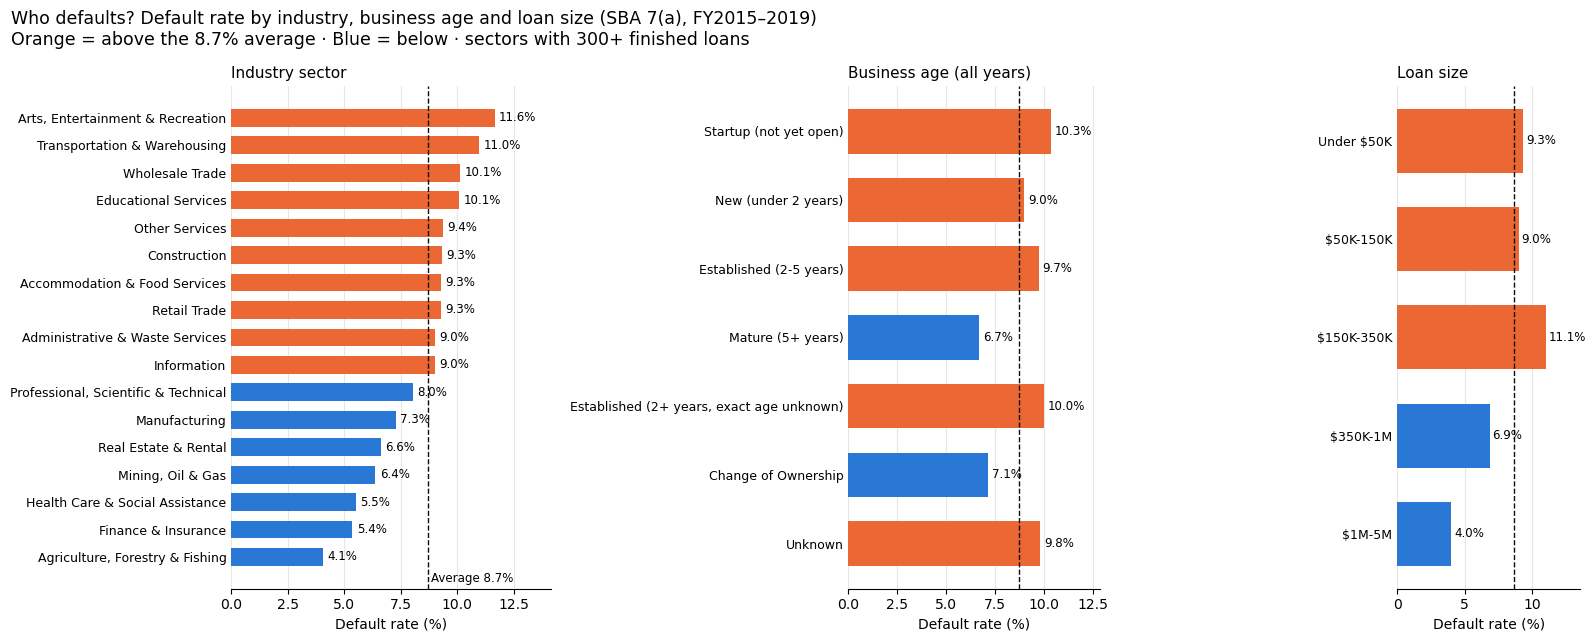

In [51]:
# Chart: default rate by industry sector, business age and loan size (loans with a known outcome)
known_q1 = df[df["outcome_known"]]
base_rate = known_q1["charged_off"].mean() * 100
panels = [
    ("Industry sector", known_q1.groupby("industry_sector")["charged_off"].agg(["mean", "size"]).query("size >= 300")
        .sort_values("mean")),
    ("Business age (all years)",
     known_q1.groupby("business_age", observed=True)["charged_off"]
        .agg(["mean", "size"]).reindex(["Startup (not yet open)", "New (under 2 years)", "Established (2-5 years)",
                                        "Mature (5+ years)", "Established (2+ years, exact age unknown)",
                                        "Change of Ownership", "Unknown"]).iloc[::-1]),
    ("Loan size", known_q1.groupby("loan_size_band", observed=True)["charged_off"].agg(["mean", "size"]).iloc[::-1]),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.4, 1.1, 0.8]})
for ax, (title, t) in zip(axes, panels):
    vals = t["mean"] * 100
    colors = np.where(vals > base_rate, "#eb6834", "#2a78d6")
    y = np.arange(len(t))
    ax.barh(y, vals, color=colors, height=0.65)
    for yi, (v, n) in enumerate(zip(vals, t["size"])):
        ax.text(v + 0.2, yi, f"{v:.1f}%", va="center", fontsize=8.5)
    ax.axvline(base_rate, color="#0b0b0b", linestyle="--", linewidth=1)
    ax.set_yticks(y, t.index, fontsize=9)
    ax.set_xlim(0, vals.max() + 2.5)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel("Default rate (%)")
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", color="#e6e6e3"); ax.set_axisbelow(True)
axes[0].text(base_rate + 0.15, -0.9, f"Average {base_rate:.1f}%", fontsize=8.5)
fig.suptitle("Who defaults? Default rate by industry, business age and loan size (SBA 7(a), FY2015–2019)\n"
             "Orange = above the 8.7% average · Blue = below · sectors with 300+ finished loans",
             x=0.01, ha="left", fontsize=12.5)
plt.tight_layout()
plt.show()


In [52]:
print("QUESTION 1: WHO DEFAULTS?")
print("=" * 70)

print("\n--- Overall ---")
print("Based on SBA loans approved in 2015-2019 that have finished, roughly 9 out of 100 loans defaulted (8.7%).")
print("This counts only loans with a known outcome (paid in full or charged off); cancelled and still-active loans are left out.")

print("\n--- Industry ---")
print("Arts & Entertainment (11.6%) and Transportation (11.0%) default the most, about 1 in 9 loans.")
print("Agriculture (4.1%), Finance (5.4%) and Health Care (5.5%) are the safest, about 1 in 20 loans.")
print("Restaurants and hotels default at 9.3%, just above average. They are not the riskiest industry.")
print("But restaurants and hotels are the largest borrowers ($23.6B lent), so even a small extra risk adds up to real dollars.")

print("\n--- Business age ---")
print("Startups default at 10.3%, but businesses under 2 years (9.0%) and 2-5 years old (9.7%) are almost as risky.")
print("Only businesses 5+ years old are clearly safer at 6.7%, about a third less likely to default.")
print("The real risk line is 5 years in business, not just 'startup'.")

print("\n--- Loan size ---")
print("Mid-size loans ($150K-$350K) default the most at 11.1%, about 1 in 9 loans.")
print("Large loans ($1M-$5M) default the least at 4.0%, less than half the average.")
print("In 11 of 20 sectors, the typical defaulted loan was smaller than the typical paid-off loan (6 sectors no difference, 3 larger).")

print("\n--- Region ---")
print("The South (which includes VA, DC and MD) defaults at 11.0%, compared with 7.0% in the Midwest.")
print("The same industry can behave very differently by region: Construction defaults at 13.6% in the South but 7.4% in the Midwest and West.")

print("\n--- Bottom line ---")
print("Riskiest profile: a $150K-$350K loan to a business under 5 years old, in entertainment, transportation or construction, in the South: 19.8% defaulted (889 loans).")
print("Safest profile: a $1M+ loan to a business 5+ years old in health care, finance or agriculture: 2.9% defaulted (1,254 loans).")

print("\n--- What the data can't tell us yet ---")
print("About 14% of loans are still being repaid and SBA hides their status, so final default rates may shift.")
print("About 1 in 4 loans over $350K are still active, so their low default rate is the least settled.")
print("Many of these loans went through COVID, so use these numbers to rank risk, not to predict future default rates.")

QUESTION 1: WHO DEFAULTS?

--- Overall ---
Based on SBA loans approved in 2015-2019 that have finished, roughly 9 out of 100 loans defaulted (8.7%).
This counts only loans with a known outcome (paid in full or charged off); cancelled and still-active loans are left out.

--- Industry ---
Arts & Entertainment (11.6%) and Transportation (11.0%) default the most, about 1 in 9 loans.
Agriculture (4.1%), Finance (5.4%) and Health Care (5.5%) are the safest, about 1 in 20 loans.
Restaurants and hotels default at 9.3%, just above average. They are not the riskiest industry.
But restaurants and hotels are the largest borrowers ($23.6B lent), so even a small extra risk adds up to real dollars.

--- Business age ---
Startups default at 10.3%, but businesses under 2 years (9.0%) and 2-5 years old (9.7%) are almost as risky.
Only businesses 5+ years old are clearly safer at 6.7%, about a third less likely to default.
The real risk line is 5 years in business, not just 'startup'.

--- Loan size ---

## Question 2: Is speed costing us? SBA Express vs PLP (vs Standard 7(a))
- **Default rate** = Charged Off ÷ (Paid in Full + Charged Off)
- **Bank loss** = amount written off × (1 − SBA guarantee %). This is what Blue Ridge itself loses.
  Express has a **50%** guarantee; PLP and Standard have **75%** (85% for loans of \$150K or less), so the same default costs the bank at least twice as much on Express.
- **Bank loss per $100 lent** answers "how much are we willing to lose?"

In [54]:
PROGRAMS = ["SBA Express", "Preferred Lender (PLP)", "Standard 7(a)"]
COLORS = {"SBA Express": "#eb6834", "Preferred Lender (PLP)": "#2a78d6", "Standard 7(a)": "#7a7a74"}

q2 = df[df["loan_program_group"].isin(PROGRAMS)].copy()
q2["loan_program_group"] = pd.Categorical(q2["loan_program_group"], categories=PROGRAMS)

# What the BANK loses after the SBA guarantee pays its share (Express 50%, PLP/Standard 75%)
q2["bank_loss"] = q2["charge_off_amount"] * (1 - q2["sba_guarantee_pct"] / 100)
q2_known = q2[q2["outcome_known"]]          # Paid in Full + Charged Off only

print(f"Loans in the 3 programs: {len(q2):,} | with a known outcome: {len(q2_known):,}")
print("Median SBA guarantee %:", q2.groupby("loan_program_group", observed=True)["sba_guarantee_pct"].median().to_dict())

Loans in the 3 programs: 273,831 | with a known outcome: 203,126
Median SBA guarantee %: {'SBA Express': 50.0, 'Preferred Lender (PLP)': 75.0, 'Standard 7(a)': 75.0}


### 2.1 Size of each program: count, share, amounts, paid vs charged off

In [56]:
def program_profile(data, by):
    """Count, share, amounts, paid/charged-off split and bank loss for any grouping."""
    by = [by] if isinstance(by, str) else by
    g = data.groupby(by, observed=True)
    out = g.agg(Loans=("loan_amount", "size"),
                Avg_amount=("loan_amount", "mean"),
                Median_amount=("loan_amount", "median"),
                Total_lent_M=("loan_amount", lambda s: s.sum() / 1e6))
    paid = data["loan_status"].eq("Paid in Full")
    co = data["loan_status"].eq("Charged Off")
    out["Paid in Full"] = paid.groupby([data[c] for c in by], observed=True).sum()
    out["Charged Off"] = co.groupby([data[c] for c in by], observed=True).sum()
    out["Paid in Full %"] = out["Paid in Full"] / out["Loans"] * 100
    out["Charged Off %"] = out["Charged Off"] / out["Loans"] * 100
    out["Default rate %"] = out["Charged Off"] / (out["Paid in Full"] + out["Charged Off"]) * 100
    out["Median paid-in-full loan"] = data[paid].groupby(by, observed=True)["loan_amount"].median()
    out["Median charged-off loan"] = data[co].groupby(by, observed=True)["loan_amount"].median()
    out["Written off $M"] = g["charge_off_amount"].sum() / 1e6
    out["Bank loss $M"] = g["bank_loss"].sum() / 1e6
    # Bank loss per $100 lent, on loans with a known outcome (same denominator as the default rate)
    k = data[data["outcome_known"]].groupby(by, observed=True)
    out["Bank loss per $100 lent"] = k["bank_loss"].sum() / k["loan_amount"].sum() * 100
    out["% finished"] = (out["Paid in Full"] + out["Charged Off"]) / (
        data[~data["loan_status"].isin(["Cancelled", "Committed (Not Disbursed)"])]
        .groupby(by, observed=True).size()) * 100
    return out

FMT = {"Loans": "{:,.0f}", "Paid in Full": "{:,.0f}", "Charged Off": "{:,.0f}",
       "Avg_amount": "${:,.0f}", "Median_amount": "${:,.0f}", "Total_lent_M": "${:,.0f}M",
       "Median paid-in-full loan": "${:,.0f}", "Median charged-off loan": "${:,.0f}",
       "Written off $M": "${:,.1f}M", "Bank loss $M": "${:,.1f}M",
       "Paid in Full %": "{:.1f}%", "Charged Off %": "{:.1f}%", "Default rate %": "{:.1f}%",
       "Bank loss per $100 lent": "${:.2f}", "% finished": "{:.0f}%", "% of loans": "{:.1f}%"}

overview = program_profile(q2, "loan_program_group")
overview.insert(1, "% of loans", overview["Loans"] / overview["Loans"].sum() * 100)
(overview.style.format(FMT, na_rep="–")
    .background_gradient(cmap="Reds", subset=["Default rate %", "Bank loss per $100 lent"]))

,Loans,% of loans,Avg_amount,Median_amount,Total_lent_M,Paid in Full,Charged Off,Paid in Full %,Charged Off %,Default rate %,Median paid-in-full loan,Median charged-off loan,Written off $M,Bank loss $M,Bank loss per $100 lent,% finished
loan_program_group,,,,,,,,,,,,,,,,
SBA Express,"144,749",52.9%,"$70,351","$49,500","$10,183M","110,394","9,743",76.3%,6.7%,8.1%,"$49,000","$30,000",$427.1M,$213.6M,$2.58,94%
Preferred Lender (PLP),"109,351",39.9%,"$783,748","$442,300","$85,704M","63,077","6,423",57.7%,5.9%,9.2%,"$468,100","$217,300","$1,757.4M",$415.3M,$0.76,71%
Standard 7(a),"19,731",7.2%,"$861,722","$486,200","$17,003M","12,505",984,63.4%,5.0%,7.3%,"$480,000","$370,500",$415.2M,$102.3M,$0.90,75%


### 2.2 Loan band × program: how much is the bank willing to lose, and which program is safer?
`RISK_APPETITE` = the most the bank accepts losing per $100 lent. It defaults to the 3-program average; change it to Blue Ridge's own number.

In [58]:
# How much is the bank willing to lose? Set the risk appetite in $ lost per $100 lent.
# Default = the average across all three programs. Change it to Blue Ridge's own number.
RISK_APPETITE = q2_known["bank_loss"].sum() / q2_known["loan_amount"].sum() * 100
print(f"Risk appetite used: ${RISK_APPETITE:.2f} lost per $100 lent (3-program average)")

band_tbl = program_profile(q2, ["loan_size_band", "loan_program_group"])
band_tbl = band_tbl[band_tbl["Loans"] >= 300]           # hide thin cells
band_tbl["Within appetite?"] = np.where(band_tbl["Bank loss per $100 lent"] <= RISK_APPETITE, "Yes", "No")

cols = ["Loans", "Median_amount", "Paid in Full", "Paid in Full %", "Charged Off", "Charged Off %",
        "Default rate %", "Bank loss $M", "Bank loss per $100 lent", "% finished", "Within appetite?"]
(band_tbl[cols].style.format(FMT, na_rep="–")
    .background_gradient(cmap="Reds", subset=["Default rate %"])
    .background_gradient(cmap="Oranges", subset=["Bank loss per $100 lent"])
    .map(lambda v: "color:#b3261e;font-weight:600" if v == "No" else "color:#1f7a3a", subset=["Within appetite?"]))

Risk appetite used: $0.99 lost per $100 lent (3-program average)


### 2.3 Band boundaries using exact amounts
Broad bands hide two things:
1. The Express cap sits **exactly at $350,000**, which falls into the "$350K–1M" band.
2. Loans pile up on round numbers ($25K, $50K, $150K, $350K) that match SBA program thresholds.

In [60]:
# Exact-amount steps instead of broad bands. $350,000 gets its own row because it is the Express cap.
EDGES = [0, 25_000, 50_000, 75_000, 100_000, 150_000, 200_000, 250_000, 300_000,
         350_000, 350_001, 500_000, 750_000, 1_000_000, 2_000_000, 5_000_001]
LABELS = ["$0-25K", "$25-50K", "$50-75K", "$75-100K", "$100-150K", "$150-200K", "$200-250K",
          "$250-300K", "$300-350K", "Exactly $350K", "$350K-500K", "$500-750K", "$750K-1M", "$1-2M", "$2-5M"]
q2["amount_step"] = pd.cut(q2["loan_amount"], EDGES, labels=LABELS, right=False)
q2_known = q2[q2["outcome_known"]]

step = (q2_known.groupby(["amount_step", "loan_program_group"], observed=True)
            .agg(Loans=("charged_off", "size"), Default_rate=("charged_off", "mean"),
                 lent=("loan_amount", "sum"), bank=("bank_loss", "sum")))
step["Default rate %"] = step["Default_rate"] * 100
step["Bank loss per $100"] = step["bank"] / step["lent"] * 100
step = step[step["Loans"] >= 100]

rate_wide = step["Default rate %"].unstack("loan_program_group")
loss_wide = step["Bank loss per $100"].unstack("loan_program_group")
n_wide = step["Loans"].unstack("loan_program_group")
step_tbl = pd.concat({"Loans": n_wide, "Default rate %": rate_wide, "Bank loss per $100": loss_wide}, axis=1)

(step_tbl.style
    .format("{:,.0f}", subset=["Loans"], na_rep="–")
    .format("{:.1f}%", subset=["Default rate %"], na_rep="–")
    .format("${:.2f}", subset=["Bank loss per $100"], na_rep="–")
    .background_gradient(cmap="Reds", subset=["Default rate %"], axis=None)
    .background_gradient(cmap="Oranges", subset=["Bank loss per $100"], axis=None))

In [61]:
# Boundaries for each program, calculated from the exact-amount steps above
exp_loss, plp_loss = loss_wide["SBA Express"], loss_wide["Preferred Lender (PLP)"]
express_cheaper = exp_loss[exp_loss < plp_loss].index.tolist()
print("1) Where Express costs the bank LESS than PLP for the same loan size:")
print("   ", ", ".join(express_cheaper))
print("   Where Express costs MORE:", ", ".join(exp_loss[exp_loss >= plp_loss].dropna().index))

print(f"\n2) Steps within the risk appetite (<= ${RISK_APPETITE:.2f} per $100 lent):")
for p in PROGRAMS:
    ok = loss_wide[p][loss_wide[p] <= RISK_APPETITE].index.tolist()
    print(f"   {p:<24}", ", ".join(ok) if ok else "none")

# Why exact amounts matter: loans pile up on round numbers that sit on SBA program thresholds
print("\n3) Loans sitting exactly on a threshold amount (count | default rate):")
for amt in [25_000, 50_000, 150_000, 350_000]:
    row = []
    for p in PROGRAMS:
        s = q2_known[(q2_known["loan_program_group"] == p) & (q2_known["loan_amount"] == amt)]["charged_off"]
        row.append(f"{p.split(' (')[0]}: {len(s):>5,} | {s.mean():5.1%}" if len(s) >= 100 else f"{p.split(' (')[0]}: –")
    print(f"   ${amt:>9,}   " + "   ".join(row))

# Neighbours of the $150K and $350K spikes for PLP
plp = q2_known[q2_known["loan_program_group"] == "Preferred Lender (PLP)"]
windows = {"$140K-149.9K": (140_000, 149_999), "Exactly $150K": (150_000, 150_000), "$150.1K-160K": (150_001, 160_000),
           "$330K-349.9K": (330_000, 349_999), "Exactly $350K": (350_000, 350_000), "$350.1K-370K": (350_001, 370_000)}
print("\n4) PLP default rate just below, at, and just above the thresholds:")
for name, (lo, hi) in windows.items():
    s = plp[plp["loan_amount"].between(lo, hi)]["charged_off"]
    print(f"   {name:<15} {len(s):>6,} loans   {s.mean():5.1%}")

1) Where Express costs the bank LESS than PLP for the same loan size:
    $150-200K, $200-250K, $250-300K, $300-350K, Exactly $350K
   Where Express costs MORE: $0-25K, $25-50K, $50-75K, $75-100K, $100-150K

2) Steps within the risk appetite (<= $0.99 per $100 lent):
   SBA Express              none
   Preferred Lender (PLP)   $0-25K, $500-750K, $750K-1M, $1-2M, $2-5M
   Standard 7(a)            $25-50K, $50-75K, $75-100K, $100-150K, $1-2M, $2-5M

3) Loans sitting exactly on a threshold amount (count | default rate):
   $   25,000   SBA Express: 12,808 | 11.5%   Preferred Lender:   405 | 33.1%   Standard 7(a): –
   $   50,000   SBA Express: 14,810 |  8.5%   Preferred Lender:   644 | 14.4%   Standard 7(a): –
   $  150,000   SBA Express: 4,450 |  5.0%   Preferred Lender: 4,569 | 27.9%   Standard 7(a):   518 | 10.6%
   $  350,000   SBA Express: 2,700 |  5.4%   Preferred Lender: 1,811 | 16.8%   Standard 7(a):   220 |  9.1%

4) PLP default rate just below, at, and just above the thresholds:

### 2.4 Histogram: where the loans sit and what each dollar costs the bank

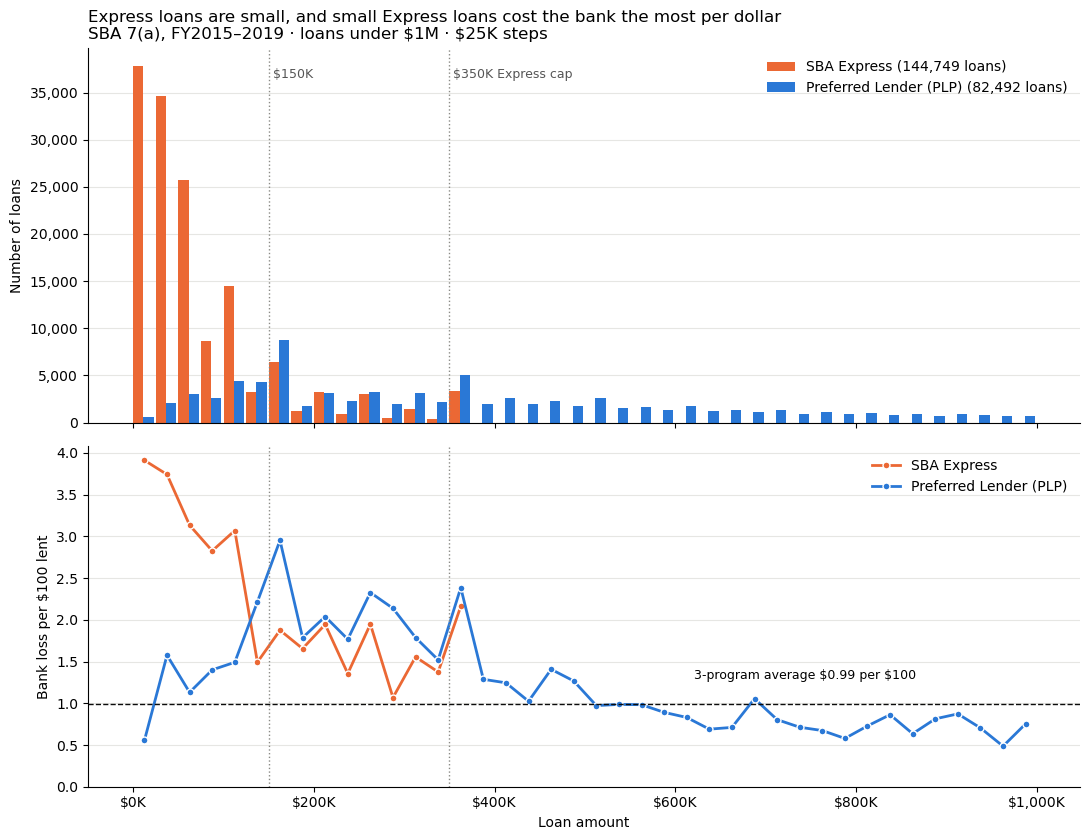

In [63]:
# Histogram of loan amounts (top) + bank loss per $100 at each loan size (bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True, gridspec_kw={"height_ratios": [1.1, 1]})
x_max = 1_000_000
bins = np.arange(0, x_max + 1, 25_000)
width = 25_000 / 2.2

# Top: side-by-side histogram bars (no overlapping colours)
for i, p in enumerate(["SBA Express", "Preferred Lender (PLP)"]):
    amt = q2.loc[(q2["loan_program_group"] == p) & (q2["loan_amount"] < x_max), "loan_amount"]
    counts, _ = np.histogram(amt, bins=bins)
    ax1.bar(bins[:-1] + (i + 0.5) * width, counts, width=width, color=COLORS[p], label=f"{p} ({len(amt):,} loans)")
ax1.set_ylabel("Number of loans")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.set_title("Express loans are small, and small Express loans cost the bank the most per dollar\n"
              "SBA 7(a), FY2015–2019 · loans under \\$1M · \\$25K steps", loc="left", fontsize=12)
ax1.legend(frameon=False, loc="upper right")

# Bottom: bank loss per $100 lent in $25K steps (known outcomes, >=100 loans per step)
k = q2_known[q2_known["loan_amount"] < x_max].copy()
k["bin"] = pd.cut(k["loan_amount"], bins, right=False)
curve = (k.groupby(["loan_program_group", "bin"], observed=True)
           .agg(n=("charged_off", "size"), bank=("bank_loss", "sum"), lent=("loan_amount", "sum")))
curve = curve[curve["n"] >= 100]
curve["loss100"] = curve["bank"] / curve["lent"] * 100
for p in ["SBA Express", "Preferred Lender (PLP)"]:
    c = curve.loc[p]
    mids = [iv.left + 12_500 for iv in c.index]
    ax2.plot(mids, c["loss100"], marker="o", ms=5, markeredgecolor="white", color=COLORS[p], label=p, linewidth=2)
ax2.axhline(RISK_APPETITE, color="#0b0b0b", linestyle="--", linewidth=1)
ax2.text(x_max * 0.62, RISK_APPETITE + 0.3, f"3-program average \\${RISK_APPETITE:.2f} per \\$100", ha="left", fontsize=9)
ax2.set_ylabel("Bank loss per \\$100 lent")
ax2.set_ylim(0, None)
ax2.legend(frameon=False, loc="upper right")

for ax in (ax1, ax2):
    for t in (150_000, 350_000):
        ax.axvline(t, color="#8a8a85", linestyle=":", linewidth=1)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color="#e6e6e3"); ax.set_axisbelow(True)
ax1.text(150_000, ax1.get_ylim()[1] * 0.92, " \\$150K", fontsize=9, color="#555")
ax1.text(350_000, ax1.get_ylim()[1] * 0.92, " \\$350K Express cap", fontsize=9, color="#555")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
ax2.set_xlabel("Loan amount")
plt.tight_layout()
plt.show()


### 2.5 Worth considering: the competitor risk of slowing approvals down
Borrowers who want fast approval often need the money now. If we push them into the slower process, many will go to a competitor.
The table shows the trade-off: how many Express borrowers a floor would slow down vs how much of Express's bank loss it would address.

In [65]:
# Trade-off: if Express were NOT allowed below a cutoff (those borrowers go through the slower PLP review),
# how many fast-approval customers are affected vs how much of Express's bank loss sits below that cutoff?
exp_k = q2_known[q2_known["loan_program_group"] == "SBA Express"]
exp_all = q2[q2["loan_program_group"] == "SBA Express"]
rows = []
for cut in [25_000, 50_000, 100_000, 150_000]:
    below_k = exp_k[exp_k["loan_amount"] < cut]
    rows.append({"Express floor": f"${cut:,}",
                 "Borrowers slowed down": (exp_all["loan_amount"] < cut).sum(),
                 "% of Express borrowers": (exp_all["loan_amount"] < cut).mean() * 100,
                 "% of Express $ lent": exp_all.loc[exp_all["loan_amount"] < cut, "loan_amount"].sum() / exp_all["loan_amount"].sum() * 100,
                 "% of Express bank loss": below_k["bank_loss"].sum() / exp_k["bank_loss"].sum() * 100,
                 "Bank loss per $100 below cutoff": below_k["bank_loss"].sum() / below_k["loan_amount"].sum() * 100})
tradeoff = pd.DataFrame(rows).set_index("Express floor")
(tradeoff.style.format({"Borrowers slowed down": "{:,.0f}", "% of Express borrowers": "{:.0f}%",
                        "% of Express $ lent": "{:.0f}%", "% of Express bank loss": "{:.0f}%",
                        "Bank loss per $100 below cutoff": "${:.2f}"}))

,Borrowers slowed down,% of Express borrowers,% of Express $ lent,% of Express bank loss,Bank loss per $100 below cutoff
Express floor,,,,,
"$25,000","37,862",26%,5%,7%,$3.91
"$50,000","72,461",50%,15%,23%,$3.80
"$100,000","106,820",74%,36%,48%,$3.36
"$150,000","124,507",86%,54%,68%,$3.14


In [66]:
print("QUESTION 2: IS SPEED COSTING US? (SBA EXPRESS vs PLP vs STANDARD 7(a))")
print("=" * 75)

print("\n--- How big each program is ---")
print("Based on the data from 2015-2019, SBA Express is the busiest program: 144,749 loans (53% of the three programs).")
print("But Express loans are small: a typical Express loan is $49,500, compared with $442,300 for PLP.")
print("In dollars, Express lent $10.2B, compared with $85.7B for PLP and $17.0B for Standard 7(a).")

print("\n--- Do Express loans default more? ---")
print("No. About 8 out of 100 finished Express loans defaulted (8.1%), compared with 9 out of 100 for PLP (9.2%) and 7 out of 100 for Standard (7.3%).")
print("Express loans that defaulted were smaller than ones that were paid off ($30,000 vs $49,000 typical size).")

print("\n--- But Express costs the bank more money ---")
print("The SBA covers only 50% of an Express loss, compared with 75% for PLP and Standard (85% on loans of $150K or less), so the bank keeps at least twice as much of the risk.")
print("For every $100 lent, the bank lost about $2.58 on Express, compared with $0.76 on PLP and $0.90 on Standard.")
print("That means each Express dollar costs the bank more than 3 times as much as a PLP dollar (3.4x).")

print("\n--- Where to draw the line on loan size ---")
print("The risk sits in the SMALLEST Express loans, not the biggest ones.")
print("Under $25K, the bank lost $3.91 per $100 on Express vs $0.55 on PLP. At $100K-$150K, it was $2.72 vs $1.87.")
print("From $150K to $350K, Express actually cost the bank LESS than PLP (about $1.50-$1.80 vs $1.70-$2.70 per $100).")
print("Across all three programs, the bank lost about $0.99 per $100 lent. No Express loan size stayed under that level.")
print("PLP loans stay under that level from about $500K and up (plus a small group of 493 PLP loans under $25K).")

print("\n--- Red flag: loans sized exactly at a program limit ---")
print("PLP loans of exactly $150,000 defaulted at 27.9% (4,569 loans), vs 10.4% just below and 7.2% just above.")
print("PLP loans of exactly $350,000 defaulted at 16.8%, vs about 7% on either side. Exactly $25,000: 33.1%.")
print("Express loans at the same amounts looked normal (5.0% at $150K, 5.4% at $350K).")
print("A loan sized exactly at a program limit deserves a second look before approval.")

print("\n--- Worth considering: the risk of losing customers to competitors ---")
print("Borrowers who want fast approval usually need the money now. If we slow them down, many will go elsewhere.")
print("Banning Express under $50K would slow down 72,461 borrowers (half of all Express borrowers) to address only 23% of Express losses.")
print("Banning Express under $25K would slow down 26% of Express borrowers to address just 7% of Express losses.")
print("Because the losses are spread across many small loans, pricing or tighter checks on small Express loans may work better than a ban.")

print("\n--- Bottom line ---")
print("Speed itself is not the problem: Express loans do not default more often.")
print("The real cost is the smaller SBA guarantee on small Express loans, where the bank keeps half the loss.")
print("Keep Express for loans of $150K-$350K, where it cost the bank less than PLP, and add tighter checks or pricing for Express loans under $150K.")

print("\n--- What the data can't tell us yet ---")
print("94% of Express loans have finished, but only 71% of PLP loans, so PLP numbers may still change.")
print("Lenders chose which borrowers went through Express, so larger Express loans likely went to stronger borrowers.")
print("The Express limit is now $500K, but this data stops at $350K. We have no evidence for Express loans between $350K and $500K.")
print("Loss amounts don't include money the bank later recovered, so real losses may be a bit lower.")

QUESTION 2: IS SPEED COSTING US? (SBA EXPRESS vs PLP vs STANDARD 7(a))

--- How big each program is ---
Based on the data from 2015-2019, SBA Express is the busiest program: 144,749 loans (53% of the three programs).
But Express loans are small: a typical Express loan is $49,500, compared with $442,300 for PLP.
In dollars, Express lent $10.2B, compared with $85.7B for PLP and $17.0B for Standard 7(a).

--- Do Express loans default more? ---
No. About 8 out of 100 finished Express loans defaulted (8.1%), compared with 9 out of 100 for PLP (9.2%) and 7 out of 100 for Standard (7.3%).
Express loans that defaulted were smaller than ones that were paid off ($30,000 vs $49,000 typical size).

--- But Express costs the bank more money ---
The SBA covers only 50% of an Express loss, compared with 75% for PLP and Standard (85% on loans of $150K or less), so the bank keeps at least twice as much of the risk.
For every $100 lent, the bank lost about $2.58 on Express, compared with $0.76 on PLP an

## Question 3: Where should we grow?
**Reframed:** Is our home region (VA/DC/MD) riskier than the rest of the country, and is that because of the *kind* of loans made here or because loans here *perform worse*? Which nearby states combine lower risk with enough loan volume to grow into?

**Breakdown**
- 3.1 Home vs nearby states vs rest of U.S.: default rate and bank loss per $100 lent
- 3.2 Is the gap about loan mix or performance? Compare each state's actual default rate with the rate expected from its industry × loan size × program mix
- 3.3 Nearby states: risk + volume (loans per year, $ lent), with a verdict for each state
- 3.4 Chart: default rate by state vs expected rate

*Expected rate* = the default rate a state would have if its loans performed like the national average for the same industry, size and program. **Actual ÷ expected above 1.0** means loans there perform worse than their mix explains.

In [68]:
HOME = ["VA", "DC", "MD"]
NEARBY = ["DE", "PA", "WV", "NC", "NJ", "NY", "KY", "TN", "OH", "SC"]   # bordering or one state away
AREA_ORDER = ["Home (VA/DC/MD)", "Nearby states", "Rest of U.S."]

geo = df[df["outcome_known"]].copy()
geo["bank_loss"] = geo["charge_off_amount"] * (1 - geo["sba_guarantee_pct"] / 100)
geo["area"] = pd.Categorical(np.select([geo["project_state"].isin(HOME), geo["project_state"].isin(NEARBY)],
                                       AREA_ORDER[:2], AREA_ORDER[2]), categories=AREA_ORDER)

# Expected default rate = what a state WOULD have if its loans performed like the national average
# for the same industry x loan size x program. Actual / expected > 1 means worse than its loan mix explains.
MIX = ["industry_sector", "loan_size_band", "loan_program_group"]
geo["expected"] = geo.groupby(MIX, observed=True)["charged_off"].transform("mean")

def geo_summary(data, by):
    g = data.groupby(by, observed=True)
    out = g.agg(Known_loans=("charged_off", "size"), Default_rate=("charged_off", "mean"),
                Expected_rate=("expected", "mean"), lent=("loan_amount", "sum"), bank=("bank_loss", "sum"))
    out["Actual vs expected (x)"] = out["Default_rate"] / out["Expected_rate"]
    out["Bank loss per $100"] = out["bank"] / out["lent"] * 100
    out[["Default_rate", "Expected_rate"]] *= 100
    return out.drop(columns=["lent", "bank"]).rename(columns={"Default_rate": "Default rate %",
                                                               "Expected_rate": "Expected from mix %"})

GEO_FMT = {"Known_loans": "{:,.0f}", "Default rate %": "{:.1f}%", "Expected from mix %": "{:.1f}%",
           "Actual vs expected (x)": "{:.2f}x", "Bank loss per $100": "${:.2f}",
           "Loans (all funded)": "{:,.0f}", "Lent ($M)": "${:,.0f}M", "Loans per year": "{:,.0f}"}

area_tbl = geo_summary(geo, "area")
print(f"National default rate: {geo['charged_off'].mean():.1%}")
area_tbl.style.format(GEO_FMT).background_gradient(cmap="Reds", subset=["Default rate %"])

National default rate: 8.7%


,Known_loans,Default rate %,Expected from mix %,Actual vs expected (x),Bank loss per $100
area,,,,,
Home (VA/DC/MD),"7,136",10.7%,8.6%,1.24x,$1.42
Nearby states,"53,258",9.1%,8.7%,1.05x,$1.14
Rest of U.S.,"164,050",8.5%,8.7%,0.97x,$0.94


In [69]:
# Home + nearby states: risk, whether the gap is mix or performance, and how much room there is to lend
funded = df[~df["loan_status"].isin(["Cancelled", "Committed (Not Disbursed)"])]
states = HOME + NEARBY
state_tbl = geo_summary(geo[geo["project_state"].isin(states)], "project_state")
state_tbl["Loans (all funded)"] = funded[funded["project_state"].isin(states)].groupby("project_state").size()
state_tbl["Lent ($M)"] = funded[funded["project_state"].isin(states)].groupby("project_state")["loan_amount"].sum() / 1e6
state_tbl["Loans per year"] = state_tbl["Loans (all funded)"] / 5
state_tbl["Group"] = np.where(state_tbl.index.isin(HOME), "Home", "Nearby")

# Simple verdict: better than its mix explains AND enough volume to grow into
state_tbl["Verdict"] = np.select(
    [state_tbl.index.isin(HOME),
     (state_tbl["Actual vs expected (x)"] <= 0.95) & (state_tbl["Known_loans"] >= 1000),
     (state_tbl["Actual vs expected (x)"] <= 0.95),
     state_tbl["Actual vs expected (x)"] >= 1.15],
    ["Current market", "Worth exploring", "Safer but small", "Riskier than home"], "About average")
state_tbl = state_tbl.sort_values("Default rate %")

(state_tbl.style.format(GEO_FMT)
    .background_gradient(cmap="Reds", subset=["Default rate %"])
    .background_gradient(cmap="RdYlGn_r", subset=["Actual vs expected (x)"], vmin=0.7, vmax=1.3))

,Known_loans,Default rate %,Expected from mix %,Actual vs expected (x),Bank loss per $100,Loans (all funded),Lent ($M),Loans per year,Group,Verdict
project_state,,,,,,,,,,
OH,"12,915",6.7%,8.8%,0.76x,$1.16,"14,708","$3,817M","2,942",Nearby,Worth exploring
KY,"1,899",7.2%,8.6%,0.84x,$1.01,"2,233",$731M,447,Nearby,Worth exploring
PA,"7,126",7.5%,8.6%,0.87x,$0.96,"8,682","$3,039M","1,736",Nearby,Worth exploring
WV,508,7.5%,8.7%,0.86x,$1.08,618,$173M,124,Nearby,Safer but small
NC,"4,600",8.7%,8.7%,1.00x,$0.70,"5,620","$3,165M","1,124",Nearby,About average
DE,629,9.1%,8.6%,1.05x,$0.92,793,$301M,159,Nearby,About average
TN,"1,913",9.7%,9.0%,1.09x,$0.77,"2,343","$1,306M",469,Nearby,About average
DC,372,10.5%,8.9%,1.18x,$1.51,464,$177M,93,Home,Current market
MD,"3,210",10.5%,8.5%,1.23x,$1.69,"3,916","$1,345M",783,Home,Current market


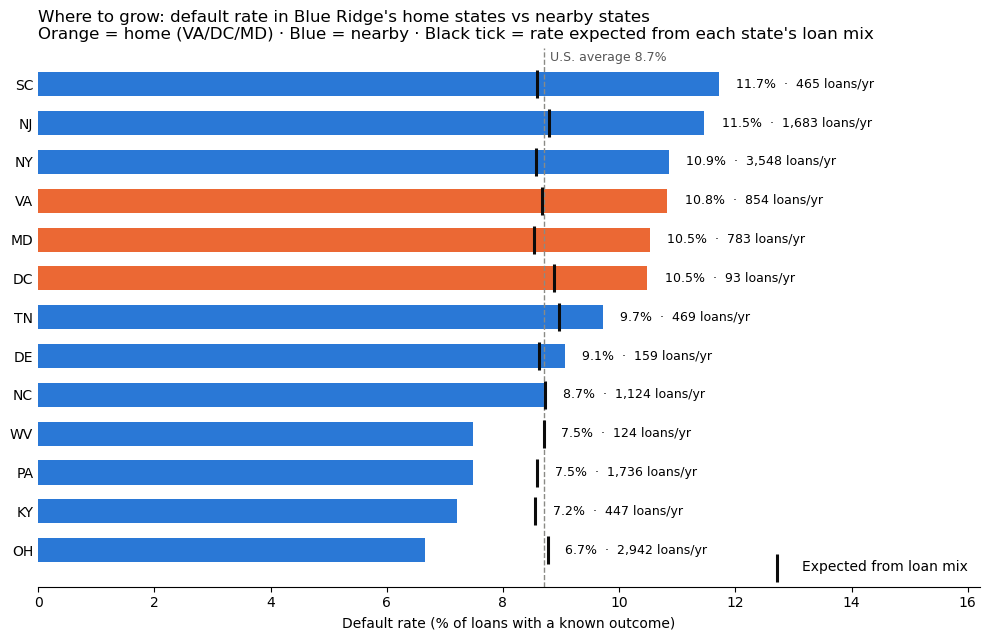

In [70]:
# Chart: default rate by state (home + nearby), with the rate each state's loan mix would predict
plot = state_tbl.sort_values("Default rate %")
colors = {"Home": "#eb6834", "Nearby": "#2a78d6"}
nat = geo["charged_off"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(plot))
ax.barh(y, plot["Default rate %"], color=[colors[g] for g in plot["Group"]], height=0.62)
ax.scatter(plot["Expected from mix %"], y, marker="|", s=380, color="#0b0b0b", linewidth=2.2,
           label="Expected from loan mix", zorder=3)
ax.axvline(nat, color="#8a8a85", linestyle="--", linewidth=1)
ax.text(nat + 0.1, len(plot) - 0.4, f"U.S. average {nat:.1f}%", fontsize=9, color="#555")

for yi, (st, row) in enumerate(plot.iterrows()):
    ax.text(max(row["Default rate %"], row["Expected from mix %"]) + 0.3, yi, f"{row['Default rate %']:.1f}%  ·  {row['Loans per year']:,.0f} loans/yr",
            va="center", fontsize=9)
ax.set_yticks(y, plot.index)
ax.set_xlim(0, plot["Default rate %"].max() + 4.5)
ax.set_xlabel("Default rate (% of loans with a known outcome)")
ax.set_title("Where to grow: default rate in Blue Ridge's home states vs nearby states\n"
             "Orange = home (VA/DC/MD) · Blue = nearby · Black tick = rate expected from each state's loan mix",
             loc="left", fontsize=12)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [71]:
print("QUESTION 3: WHERE SHOULD WE GROW?")
print("=" * 70)

print("\n--- Our home region vs the rest of the country ---")
print("Based on the data from 2015-2019, SBA loans in VA/DC/MD defaulted at 10.7%, about 11 out of 100 finished loans.")
print("States that are not nearby defaulted at 8.5%, about 8 or 9 out of 100. Nearby states sit in between at 9.1%.")
print("Each home state is above the national average of 8.7%: VA 10.8%, MD 10.5%, DC 10.5%.")

print("\n--- Is it the type of loans, or how they perform? ---")
print("Given the industries, loan sizes and programs in VA/DC/MD, we would expect only 8.6% to default.")
print("The real rate is 10.7%, about 24% higher than expected. So the gap is NOT because of riskier types of loans.")
print("Loans in our region simply perform worse than similar loans elsewhere. That points to how loans are made here (see Question 4).")

print("\n--- Nearby states worth exploring ---")
print("Pennsylvania: 7.5% default rate, 13% better than its loan mix predicts, about 1,736 SBA loans a year.")
print("Ohio: 6.7% default rate, 24% better than expected, about 2,942 loans a year, the largest safe market nearby.")
print("Kentucky: 7.2% default rate, 16% better than expected, about 447 loans a year.")
print("West Virginia is also safer (7.5%), but small: only about 124 loans a year.")
print("North Carolina is average (8.7%) but has the lowest bank loss nearby: $0.70 per $100 lent vs $1.24-$1.69 in our home states.")

print("\n--- Nearby states to be careful with ---")
print("New York (10.9%), New Jersey (11.5%) and South Carolina (11.7%) are as risky as, or riskier than, our home region.")
print("New York is the biggest nearby market (about 3,548 loans a year), but it would add risk, not reduce it.")

print("\n--- Bottom line ---")
print("Before expanding, look at how loans are made at home: our region underperforms by about 2 points for reasons other than loan type.")
print("For expansion, Pennsylvania is the most natural next step: it borders Maryland, it's large, and its loans perform better than expected.")

print("\n--- What the data can't tell us ---")
print("State numbers show where the loan is used, not where Blue Ridge could compete. Local competition, branch cost and pricing are not in this data.")
print("DC has only 372 finished loans, so its rate is less certain.")
print("These are 2015-2019 loans that went through COVID. Regions hit harder by COVID may look worse than normal.")


QUESTION 3: WHERE SHOULD WE GROW?

--- Our home region vs the rest of the country ---
Based on the data from 2015-2019, SBA loans in VA/DC/MD defaulted at 10.7%, about 11 out of 100 finished loans.
States that are not nearby defaulted at 8.5%, about 8 or 9 out of 100. Nearby states sit in between at 9.1%.
Each home state is above the national average of 8.7%: VA 10.8%, MD 10.5%, DC 10.5%.

--- Is it the type of loans, or how they perform? ---
Given the industries, loan sizes and programs in VA/DC/MD, we would expect only 8.6% to default.
The real rate is 10.7%, about 24% higher than expected. So the gap is NOT because of riskier types of loans.
Loans in our region simply perform worse than similar loans elsewhere. That points to how loans are made here (see Question 4).

--- Nearby states worth exploring ---
Pennsylvania: 7.5% default rate, 13% better than its loan mix predicts, about 1,736 SBA loans a year.
Ohio: 6.7% default rate, 24% better than expected, about 2,942 loans a year, t

### 3.5 Our region vs the rest of the U.S. by industry sector
**Question:** Is our region's higher default rate spread across every industry, or concentrated in a few?

- Default rate by sector: VA/DC/MD combined vs the rest of the U.S., with the gap in percentage points
- Each home state on its own (VA, MD, DC)
- How much of our region's lending each sector makes up
- Is each gap real? (two-proportion z-test: p-value under 0.05 = a real difference, not chance)

Rules: region rates need at least 100 finished loans; single-state rates need at least 50 (read those with care).

In [73]:
# DMV vs rest of U.S. by industry sector (loans with a known outcome)
MIN_N = 100                                    # hide DMV rates built on fewer finished loans
STATE_MIN = 50                                 # single states are smaller, so a lower bar (read with care)
sec = geo.assign(where=np.where(geo["project_state"].isin(HOME), "DMV", "Rest of U.S."))

def rate_block(data, prefix):
    g = data.groupby("industry_sector")["charged_off"].agg(["size", "sum", "mean"])
    return g.rename(columns={"size": f"{prefix} loans", "sum": f"{prefix} defaults", "mean": f"{prefix} default %"})

dmv_sec = pd.concat([rate_block(sec[sec["where"] == "DMV"], "DMV"),
                     rate_block(sec[sec["where"] == "Rest of U.S."], "Rest")], axis=1)
for st in HOME:                                # each home state on its own
    s = sec[sec["project_state"] == st].groupby("industry_sector")["charged_off"].agg(["size", "mean"])
    dmv_sec[f"{st} default %"] = s["mean"].where(s["size"] >= STATE_MIN)
    dmv_sec[f"{st} loans"] = s["size"]

dmv_sec["DMV share of its loans %"] = dmv_sec["DMV loans"] / dmv_sec["DMV loans"].sum() * 100
dmv_sec[[c for c in dmv_sec if c.endswith("default %")]] *= 100
dmv_sec["Gap (pts)"] = dmv_sec["DMV default %"] - dmv_sec["Rest default %"]
dmv_sec["DMV vs rest (x)"] = dmv_sec["DMV default %"] / dmv_sec["Rest default %"]

# Is the gap real? Two-proportion z-test, DMV vs rest of U.S.
from scipy import stats
p1, p2 = dmv_sec["DMV default %"] / 100, dmv_sec["Rest default %"] / 100
n1, n2 = dmv_sec["DMV loans"], dmv_sec["Rest loans"]
pool = (dmv_sec["DMV defaults"] + dmv_sec["Rest defaults"]) / (n1 + n2)
z = (p1 - p2) / np.sqrt(pool * (1 - pool) * (1 / n1 + 1 / n2))
dmv_sec["p-value"] = 2 * (1 - stats.norm.cdf(z.abs()))
dmv_sec["Verdict"] = np.select([dmv_sec["DMV loans"] < MIN_N, dmv_sec["p-value"] >= 0.05, dmv_sec["Gap (pts)"] > 0],
                               ["Too few DMV loans", "No real difference", "DMV riskier"], "DMV safer")
dmv_sec = dmv_sec[dmv_sec["DMV loans"] >= 30].sort_values("DMV default %", ascending=False)

cols = ["DMV loans", "DMV share of its loans %", "DMV default %", "Rest default %", "Gap (pts)", "DMV vs rest (x)",
        "VA default %", "MD default %", "DC default %", "p-value", "Verdict"]
(dmv_sec[cols].style
    .format({"DMV loans": "{:,.0f}", "DMV share of its loans %": "{:.1f}%", "DMV default %": "{:.1f}%",
             "Rest default %": "{:.1f}%", "Gap (pts)": "{:+.1f}", "DMV vs rest (x)": "{:.2f}x",
             "VA default %": "{:.1f}%", "MD default %": "{:.1f}%", "DC default %": "{:.1f}%", "p-value": "{:.3f}"},
            na_rep="–")
    .background_gradient(cmap="Reds", subset=["DMV default %", "Rest default %", "VA default %", "MD default %", "DC default %"], axis=None)
    .background_gradient(cmap="RdYlGn_r", subset=["Gap (pts)"], vmin=-4, vmax=4)
    .map(lambda v: "color:#b3261e;font-weight:600" if v == "DMV riskier" else
                   ("color:#1f7a3a;font-weight:600" if v == "DMV safer" else "color:#777"), subset=["Verdict"]))

,DMV loans,DMV share of its loans %,DMV default %,Rest default %,Gap (pts),DMV vs rest (x),VA default %,MD default %,DC default %,p-value,Verdict
industry_sector,,,,,,,,,,,
"Arts, Entertainment & Recreation",326,4.6%,14.4%,11.5%,+2.9,1.25x,17.3%,11.4%,–,0.111,No real difference
Transportation & Warehousing,276,3.9%,13.4%,10.9%,+2.5,1.23x,11.6%,15.4%,–,0.189,No real difference
Construction,712,10.0%,12.8%,9.2%,+3.6,1.39x,11.3%,14.1%,–,0.001,DMV riskier
Retail Trade,820,11.5%,12.6%,9.2%,+3.4,1.37x,13.8%,11.7%,10.3%,0.001,DMV riskier
Other Services,668,9.4%,12.4%,9.3%,+3.2,1.34x,11.8%,12.1%,–,0.006,DMV riskier
Accommodation & Food Services,951,13.3%,12.4%,9.2%,+3.2,1.35x,11.9%,13.4%,10.8%,0.001,DMV riskier
Administrative & Waste Services,372,5.2%,12.4%,8.9%,+3.5,1.39x,13.7%,10.8%,–,0.021,DMV riskier
Real Estate & Rental,97,1.4%,11.3%,6.5%,+4.8,1.74x,–,–,–,0.058,Too few DMV loans
Information,95,1.3%,10.5%,8.9%,+1.6,1.18x,–,–,–,0.595,Too few DMV loans


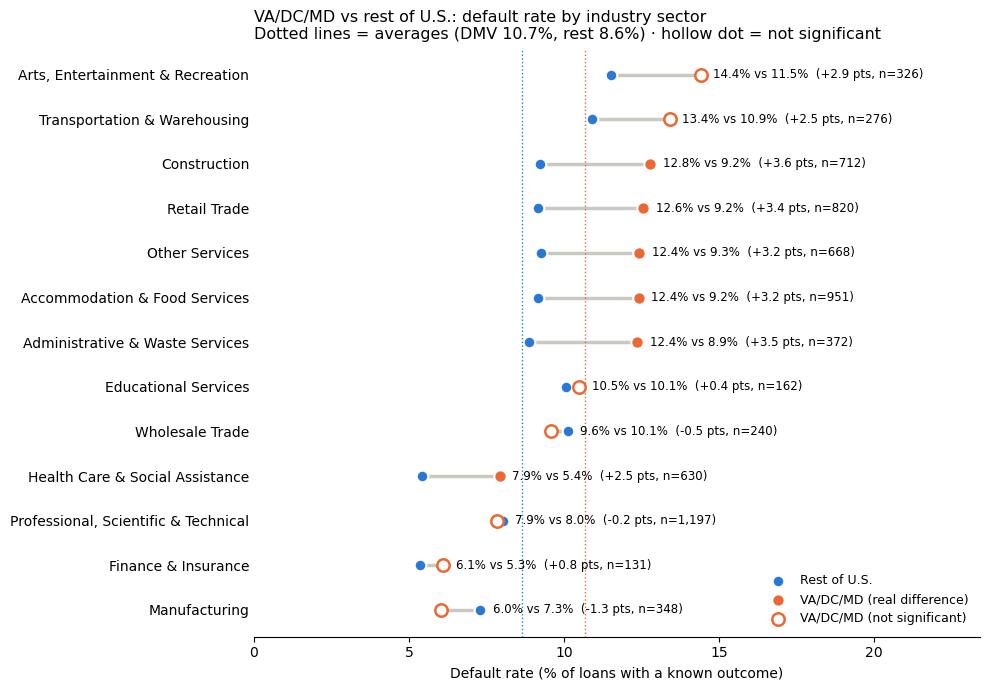

In [74]:
# Chart: DMV vs rest of U.S. default rate by sector (dumbbell), sectors with >= 100 DMV loans
p = dmv_sec[dmv_sec["DMV loans"] >= MIN_N].sort_values("DMV default %")
y = np.arange(len(p))
fig, ax = plt.subplots(figsize=(10, 7))
ax.hlines(y, p["Rest default %"], p["DMV default %"], color="#c9c8c2", linewidth=2.5, zorder=1)
ax.scatter(p["Rest default %"], y, s=70, color="#2a78d6", edgecolor="white", linewidth=1.5, zorder=2, label="Rest of U.S.")
sig = p["Verdict"].isin(["DMV riskier", "DMV safer"])
ax.scatter(p.loc[sig, "DMV default %"], y[sig.values], s=80, color="#eb6834", edgecolor="white", linewidth=1.5,
           zorder=3, label="VA/DC/MD (real difference)")
ax.scatter(p.loc[~sig, "DMV default %"], y[~sig.values], s=80, facecolor="white", edgecolor="#eb6834", linewidth=1.8,
           zorder=3, label="VA/DC/MD (not significant)")
for yi, (_, r) in enumerate(p.iterrows()):
    right = max(r["DMV default %"], r["Rest default %"])
    ax.text(right + 0.4, yi, f"{r['DMV default %']:.1f}% vs {r['Rest default %']:.1f}%  ({r['Gap (pts)']:+.1f} pts, n={r['DMV loans']:,.0f})",
            va="center", fontsize=8.5)
dmv_avg, rest_avg = geo[geo["project_state"].isin(HOME)]["charged_off"].mean() * 100, geo[~geo["project_state"].isin(HOME)]["charged_off"].mean() * 100
ax.axvline(dmv_avg, color="#eb6834", linestyle=":", linewidth=1)
ax.axvline(rest_avg, color="#2a78d6", linestyle=":", linewidth=1)
ax.set_yticks(y, p.index)
ax.set_xlim(0, p[["DMV default %", "Rest default %"]].max().max() + 9)
ax.set_xlabel("Default rate (% of loans with a known outcome)")
ax.set_title(f"VA/DC/MD vs rest of U.S.: default rate by industry sector\n"
             f"Dotted lines = averages (DMV {dmv_avg:.1f}%, rest {rest_avg:.1f}%) · hollow dot = not significant",
             loc="left", fontsize=11.5)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [75]:
print("QUESTION 3 (DETAIL): OUR REGION vs THE REST OF THE U.S., BY INDUSTRY")
print("=" * 72)

print("\n--- The overall gap ---")
print("Based on the data from 2015-2019, loans in VA/DC/MD defaulted at 10.7%, vs 8.6% in the rest of the U.S. (all other states, including nearby ones).")

print("\n--- Where our region is clearly riskier (real differences, not chance) ---")
print("Construction: 12.8% here vs 9.2% elsewhere (+3.6 points). Maryland is highest at 14.1%.")
print("Administrative & Waste Services (office support, cleaning, staffing): 12.4% vs 8.9% (+3.5 points). Virginia is highest at 13.7%.")
print("Retail: 12.6% vs 9.2% (+3.4 points). Virginia is highest at 13.8%.")
print("Restaurants & Hotels: 12.4% vs 9.2% (+3.2 points). This is our region's 2nd-largest sector (13% of loans).")
print("Other Services (salons, repair, etc.): 12.4% vs 9.3% (+3.2 points).")
print("Health Care: 7.9% vs 5.4% (+2.5 points). Still a safe sector, but less safe here than elsewhere.")

print("\n--- Where our region is no different from the rest of the country ---")
print("Professional, Scientific & Technical services, our BIGGEST sector (17% of loans): 7.9% here vs 8.0% elsewhere.")
print("Manufacturing (6.0% vs 7.3%), Wholesale (9.6% vs 10.1%), Education and Finance show no real difference.")
print("Arts & Entertainment (14.4% vs 11.5%) and Transportation (13.4% vs 10.9%) look higher here, but the gap is not statistically significant.")

print("\n--- What this means ---")
print("The extra risk is NOT spread evenly. It sits in small, local, customer-facing businesses: construction, retail, restaurants, services.")
print("These five riskier sectors make up about half of our region's SBA loans (49%) and explain about 1.7 of the 2.0-point regional gap (81%).")
print("Professional services, our largest sector, performs just like the national average and is a safe area to grow.")
print("Combined with Question 4, much of this local risk comes from loans made by out-of-state lenders, where local knowledge matters most.")

print("\n--- What the data can't tell us ---")
print("DC has too few loans to show most sectors on its own. Single-state numbers are based on 50+ loans and are less certain.")
print("Real Estate, Information and Agriculture have fewer than 100 finished loans in our region, so they are not judged here.")

QUESTION 3 (DETAIL): OUR REGION vs THE REST OF THE U.S., BY INDUSTRY

--- The overall gap ---
Based on the data from 2015-2019, loans in VA/DC/MD defaulted at 10.7%, vs 8.6% in the rest of the U.S. (all other states, including nearby ones).

--- Where our region is clearly riskier (real differences, not chance) ---
Construction: 12.8% here vs 9.2% elsewhere (+3.6 points). Maryland is highest at 14.1%.
Administrative & Waste Services (office support, cleaning, staffing): 12.4% vs 8.9% (+3.5 points). Virginia is highest at 13.7%.
Retail: 12.6% vs 9.2% (+3.4 points). Virginia is highest at 13.8%.
Restaurants & Hotels: 12.4% vs 9.2% (+3.2 points). This is our region's 2nd-largest sector (13% of loans).
Other Services (salons, repair, etc.): 12.4% vs 9.3% (+3.2 points).
Health Care: 7.9% vs 5.4% (+2.5 points). Still a safe sector, but less safe here than elsewhere.

--- Where our region is no different from the rest of the country ---
Professional, Scientific & Technical services, our BIGGE

## Question 4: How do we compare with competitors?
**Reframed:** For the same kind of loan (same state, industry, size and program), do lenders based in the borrower's own state default less than out-of-state lenders? How do big national banks and non-bank lenders compare with local banks? Is there evidence that local knowledge lowers risk?

**Breakdown**
- 4.1 Nationwide: in-state vs out-of-state lenders, and by lender type (local / regional / national bank, credit union, non-bank)
- 4.2 A fair comparison: actual vs expected default rate for the *same* state × industry × size × program
- 4.3 VA/DC/MD only: who lends in our market and how their loans perform
- 4.4 Chart: default rate by lender type, in-state vs out-of-state, U.S. vs VA/DC/MD

**Definitions**
- **In-state lender:** the lender's headquarters is in the same state as the borrower.
- **Lender footprint:** the number of states a lender lent in: local 1–4, regional 5–39, national 40+.

In [77]:
# Lender footprint = number of states a lender made loans in (FY2015-2019). Used to separate
# local banks from regional and big national banks. Non-banks and credit unions keep their own groups.
footprint = df.groupby("lender_id")["project_state"].nunique()
CLASS_ORDER = ["Local bank (1-4 states)", "Regional bank (5-39 states)", "National bank (40+ states)",
               "Credit union", "Non-bank lender"]

comp = df[df["outcome_known"]].copy()
comp["footprint"] = comp["lender_id"].map(footprint)
comp["lender_class"] = pd.Categorical(np.select(
    [comp["lender_type"].eq("Non-Bank Lender"), comp["lender_type"].eq("Credit Union"),
     comp["footprint"] >= 40, comp["footprint"] >= 5],
    ["Non-bank lender", "Credit union", "National bank (40+ states)", "Regional bank (5-39 states)"],
    "Local bank (1-4 states)"), categories=CLASS_ORDER)
comp["lender_location"] = np.where(comp["out_of_state_lender"].eq("Yes"), "Out-of-state", "In-state")

# Fair comparison: expected rate for the SAME state x industry x loan size x program
FAIR = ["project_state", "industry_sector", "loan_size_band", "loan_program_group"]
comp["expected"] = comp.groupby(FAIR, observed=True)["charged_off"].transform("mean")

def lender_summary(data, by, min_n=100):
    g = data.groupby(by, observed=True)
    out = g.agg(Loans=("charged_off", "size"), Default=("charged_off", "mean"), Expected=("expected", "mean"))
    out["Actual vs expected (x)"] = out["Default"] / out["Expected"]
    out[["Default", "Expected"]] *= 100
    out = out.rename(columns={"Default": "Default rate %", "Expected": "Expected for same loans %"})
    return out[out["Loans"] >= min_n]

LFMT = {"Loans": "{:,.0f}", "Default rate %": "{:.1f}%", "Expected for same loans %": "{:.1f}%",
        "Actual vs expected (x)": "{:.2f}x"}

print("NATIONWIDE: in-state vs out-of-state lenders")
display(lender_summary(comp, "lender_location").style.format(LFMT))
print("NATIONWIDE: by lender type")
display(lender_summary(comp, "lender_class").style.format(LFMT)
        .background_gradient(cmap="RdYlGn_r", subset=["Actual vs expected (x)"], vmin=0.6, vmax=1.4))

NATIONWIDE: in-state vs out-of-state lenders


,Loans,Default rate %,Expected for same loans %,Actual vs expected (x)
lender_location,,,,
In-state,"80,472",5.9%,7.6%,0.77x
Out-of-state,"143,972",10.3%,9.3%,1.10x


NATIONWIDE: by lender type


,Loans,Default rate %,Expected for same loans %,Actual vs expected (x)
lender_class,,,,
Local bank (1-4 states),"32,184",4.2%,7.1%,0.60x
Regional bank (5-39 states),"92,238",7.5%,8.3%,0.91x
National bank (40+ states),"85,734",11.6%,9.7%,1.20x
Credit union,"7,018",5.1%,7.6%,0.67x
Non-bank lender,"7,270",12.6%,10.8%,1.16x


In [78]:
# Blue Ridge's own market: VA / DC / MD
home = comp[comp["project_state"].isin(HOME)]
print(f"VA/DC/MD loans with a known outcome: {len(home):,}  |  made by out-of-state lenders: {home['lender_location'].eq('Out-of-state').mean():.0%}")
display(lender_summary(home, "lender_location").style.format(LFMT))
display(lender_summary(home, ["lender_class", "lender_location"], min_n=30).style.format(LFMT)
        .background_gradient(cmap="RdYlGn_r", subset=["Actual vs expected (x)"], vmin=0.4, vmax=1.6))

# Biggest SBA lenders in VA/DC/MD (>=100 known-outcome loans)
top = (home.groupby("lender_name")
           .agg(Loans=("charged_off", "size"), Default=("charged_off", "mean"),
                HQ_state=("lender_state", lambda s: s.mode().iat[0]), Type=("lender_class", lambda s: s.mode().iat[0]))
           .query("Loans >= 100").sort_values("Loans", ascending=False))
top["Default"] *= 100
top.rename(columns={"Default": "Default rate %"}).style.format({"Loans": "{:,.0f}", "Default rate %": "{:.1f}%"})\
   .background_gradient(cmap="Reds", subset=["Default rate %"])

VA/DC/MD loans with a known outcome: 7,136  |  made by out-of-state lenders: 87%


,Loans,Default rate %,Expected for same loans %,Actual vs expected (x)
lender_location,,,,
In-state,927,3.8%,9.1%,0.42x
Out-of-state,"6,209",11.7%,10.9%,1.07x


,Loans,Default rate %,HQ_state,Type
lender_name,,,,
Manufacturers and Traders Trust Company,"1,917",10.6%,NY,Regional bank (5-39 states)
Wells Fargo Bank National Association,905,9.9%,SD,National bank (40+ states)
Truist Bank,455,5.3%,NC,Regional bank (5-39 states)
"TD Bank, National Association",418,19.9%,DE,Regional bank (5-39 states)
Atlantic Union Bank,255,3.5%,VA,Regional bank (5-39 states)
Live Oak Banking Company,193,5.2%,NC,National bank (40+ states)
"PNC Bank, National Association",186,4.8%,DE,National bank (40+ states)
Celtic Bank Corporation,179,25.7%,UT,National bank (40+ states)
Primis Bank,174,2.9%,VA,Regional bank (5-39 states)


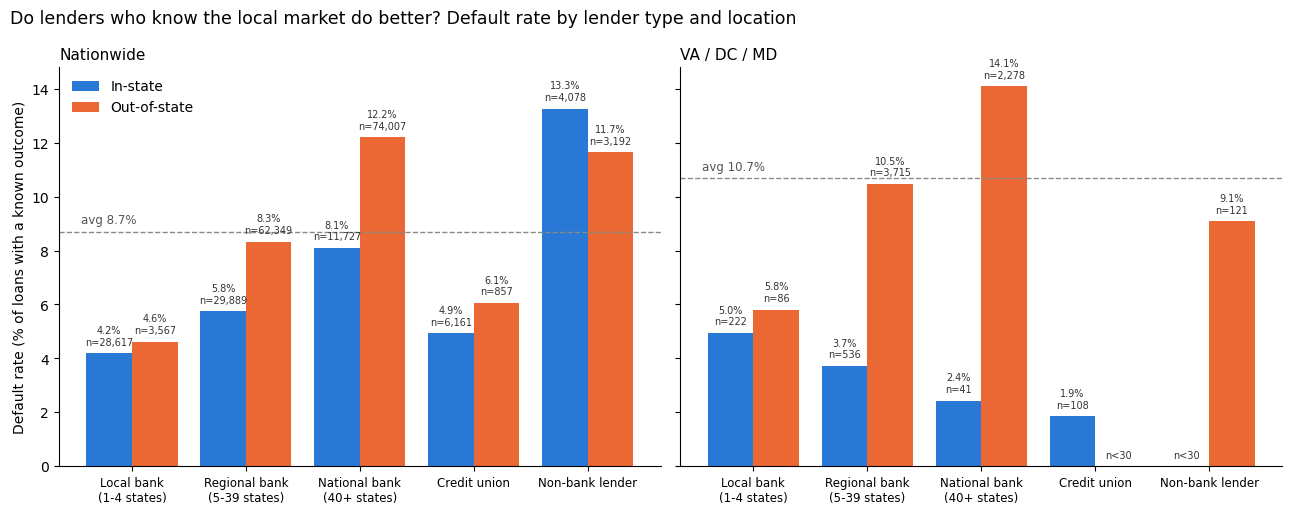

In [79]:
# Chart: default rate by lender type, in-state vs out-of-state, nationwide vs VA/DC/MD
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
loc_colors = {"In-state": "#2a78d6", "Out-of-state": "#eb6834"}
for ax, (title, data) in zip(axes, [("Nationwide", comp), ("VA / DC / MD", home)]):
    t = data.groupby(["lender_class", "lender_location"], observed=True)["charged_off"].agg(["mean", "size"])
    x = np.arange(len(CLASS_ORDER)); w = 0.4
    for i, loc in enumerate(["In-state", "Out-of-state"]):
        vals = [t.loc[(c, loc), "mean"] * 100 if (c, loc) in t.index and t.loc[(c, loc), "size"] >= 30 else np.nan
                for c in CLASS_ORDER]
        ns = [t.loc[(c, loc), "size"] if (c, loc) in t.index else 0 for c in CLASS_ORDER]
        bars = ax.bar(x + (i - 0.5) * w, vals, w, color=loc_colors[loc], label=loc)
        for xi, v, n in zip(x + (i - 0.5) * w, vals, ns):
            ax.text(xi, (0 if np.isnan(v) else v) + 0.3, "n<30" if np.isnan(v) else f"{v:.1f}%\nn={n:,}",
                    ha="center", fontsize=7, color="#333")
    avg = data["charged_off"].mean() * 100
    ax.axhline(avg, color="#8a8a85", linestyle="--", linewidth=1)
    ax.text(-0.45, avg + 0.3, f"avg {avg:.1f}%", ha="left", fontsize=8.5, color="#555")
    ax.set_xticks(x, [c.replace(" (", "\n(") for c in CLASS_ORDER], fontsize=8.5)
    ax.set_title(title, loc="left", fontsize=11)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("Default rate (% of loans with a known outcome)")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Do lenders who know the local market do better? Default rate by lender type and location",
             x=0.01, ha="left", fontsize=12.5)
plt.tight_layout()
plt.show()

In [80]:
print("QUESTION 4: HOW DO WE COMPARE WITH COMPETITORS?")
print("=" * 70)

print("\n--- Out-of-state lenders ---")
print("Based on the data from 2015-2019, loans from lenders based in the borrower's own state defaulted at 5.9%, about 6 out of 100.")
print("Loans from out-of-state lenders defaulted at 10.3%, about 10 out of 100, almost twice as often.")
print("Even compared with the SAME kind of loan (same state, industry, size and program), in-state lenders did 23% better than expected and out-of-state lenders 10% worse.")

print("\n--- By type of lender ---")
print("Local banks (lending in 1-4 states) had the lowest default rate: 4.2%, about 40% better than expected for the same loans.")
print("Credit unions: 5.1% (33% better than expected). Regional banks: 7.5% (9% better).")
print("Big national banks (lending in 40+ states): 11.6%, about 20% worse than expected.")
print("Non-bank lenders: 12.6%, about 16% worse than expected.")
print("One exception to the local pattern: nationwide, in-state non-bank lenders did worse than out-of-state ones (13.3% vs 11.7%).")

print("\n--- In our own market (VA/DC/MD) ---")
print("87% of SBA loans in our region were made by out-of-state lenders. Local lenders are a small share of the market.")
print("In-state lenders' loans here defaulted at just 3.8%, compared with 11.7% for out-of-state lenders, about 3 times lower.")
print("For the same kind of loans, in-state lenders did about 58% better than expected. Out-of-state lenders did 7% worse.")
print("Local examples: Atlantic Union Bank (VA) 3.5% and Primis Bank (VA) 2.9%, vs TD Bank 19.9% and Celtic Bank (UT) 25.7%.")

print("\n--- Link to Question 3 ---")
print("Our region's higher default rate is largely driven by out-of-state lenders, who make most of the loans here.")
print("If our region had the national mix of lenders (36% in-state instead of 13%), its default rate would be about 8.9%, close to the 8.7% national average.")
print("That suggests the region itself is not the problem. How the loans are made is.")

print("\n--- Bottom line ---")
print("Yes, local knowledge looks like a real advantage: local lenders' loans default far less, even for the same type of loan.")
print("Blue Ridge can grow by winning borrowers from out-of-state lenders in its own market, where it has the edge, instead of only expanding outward.")

print("\n--- What the data can't tell us ---")
print("'Out-of-state' is based on the lender's headquarters. Big banks with local branches (e.g. M&T, Wells Fargo, PNC) still count as out-of-state.")
print("SBA's 'non-bank' lenders are mostly mission lenders (51% are in Special Initiative programs), not online fintechs.")
print("Online lenders often work through partner banks (e.g. Celtic Bank), so they show up as banks in this data.")
print("Only 927 loans in our region came from in-state lenders, so local numbers are less certain than the national ones.")
print("Local lenders may also pick safer borrowers. The data shows they do better, but not exactly why.")

QUESTION 4: HOW DO WE COMPARE WITH COMPETITORS?

--- Out-of-state lenders ---
Based on the data from 2015-2019, loans from lenders based in the borrower's own state defaulted at 5.9%, about 6 out of 100.
Loans from out-of-state lenders defaulted at 10.3%, about 10 out of 100, almost twice as often.
Even compared with the SAME kind of loan (same state, industry, size and program), in-state lenders did 23% better than expected and out-of-state lenders 10% worse.

--- By type of lender ---
Local banks (lending in 1-4 states) had the lowest default rate: 4.2%, about 40% better than expected for the same loans.
Credit unions: 5.1% (33% better than expected). Regional banks: 7.5% (9% better).
Big national banks (lending in 40+ states): 11.6%, about 20% worse than expected.
Non-bank lenders: 12.6%, about 16% worse than expected.
One exception to the local pattern: nationwide, in-state non-bank lenders did worse than out-of-state ones (13.3% vs 11.7%).

--- In our own market (VA/DC/MD) ---
87%

## Question 5: When a loan goes bad, how bad and how fast?
**Reframed:** For loans that charged off, how many months after approval were they written off, and in which years of a loan's life is the risk highest? When a loan fails, what share of it is lost, and how much of that does the bank itself absorb after the SBA guarantee?

**Breakdown**
- 5.1 Timing: months from approval to charge-off (percentiles, loan year by loan year, and the oldest cohorts for the fullest view)
- 5.2 Severity: % of the loan written off and the bank's share, by program, size, collateral, credit line and term
- 5.3 Calendar check: when charge-offs actually happened (COVID effect)
- 5.4 Chart: how fast (share of charge-offs by loan year) and how bad (severity histogram)

Population: charged-off loans only (19,533).

In [82]:
co = df[df["loan_status"].eq("Charged Off")].copy()
co["bank_loss"] = co["charge_off_amount"] * (1 - co["sba_guarantee_pct"] / 100)
# A few write-offs are larger than the original loan (e.g. revolving lines, fees). Cap severity at 100% for summaries.
print(f"Charged-off loans: {len(co):,} | written off more than 100% of the loan: {(co['charge_off_pct_of_loan'] > 100).sum():,} (capped at 100%)")
co["severity_%"] = co["charge_off_pct_of_loan"].clip(upper=100)
co["term_band"] = pd.Categorical(co["term_band"], ["Up to 5 yrs", "5-10 yrs", "10-20 yrs", "20+ yrs"], ordered=True)
co["bank_share_%"] = (co["bank_loss"] / co["loan_amount"] * 100).clip(upper=100)
co["loan_year"] = pd.cut(co["months_to_charge_off"], bins=[0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 150],
                         labels=["Year 1", "Year 2", "Year 3", "Year 4", "Year 5", "Year 6", "Year 7",
                                 "Year 8", "Year 9", "Year 10", "Year 11+"])

# When do charge-offs happen? (months from approval to charge-off)
timing = co["months_to_charge_off"].describe(percentiles=[.1, .25, .5, .75, .9])
print("\nMonths from approval to charge-off:")
print(f"  10% by month {timing['10%']:.0f} | 25% by {timing['25%']:.0f} | half by {timing['50%']:.0f} | 75% by {timing['75%']:.0f} | 90% by {timing['90%']:.0f}")

# Oldest cohorts (FY2015-16) have been watched the longest (~10 years), so they show the fullest picture
old = co[co["approval_fiscal_year"] <= 2016]["months_to_charge_off"]
print(f"  FY2015-16 loans only (fullest view): half charged off by month {old.median():.0f}, 75% by month {old.quantile(.75):.0f}")

year_tbl = co["loan_year"].value_counts().sort_index().to_frame("Charge-offs")
year_tbl["% of charge-offs"] = year_tbl["Charge-offs"] / year_tbl["Charge-offs"].sum() * 100
year_tbl["Cumulative %"] = year_tbl["% of charge-offs"].cumsum()
year_tbl.style.format({"Charge-offs": "{:,.0f}", "% of charge-offs": "{:.1f}%", "Cumulative %": "{:.0f}%"})\
    .bar(subset=["% of charge-offs"], color="#f3b49a")

Charged-off loans: 19,533 | written off more than 100% of the loan: 762 (capped at 100%)

Months from approval to charge-off:
  10% by month 24 | 25% by 37 | half by 55 | 75% by 76 | 90% by 92
  FY2015-16 loans only (fullest view): half charged off by month 55, 75% by month 79


,Charge-offs,% of charge-offs,Cumulative %
loan_year,,,
Year 1,221,1.1%,1%
Year 2,"1,751",9.0%,10%
Year 3,"2,897",14.8%,25%
Year 4,"3,234",16.6%,42%
Year 5,"3,075",15.7%,57%
Year 6,"2,752",14.1%,71%
Year 7,"2,456",12.6%,84%
Year 8,"1,817",9.3%,93%
Year 9,783,4.0%,97%


In [83]:
# How bad, how fast, by loan type
def loss_profile(data, by):
    g = data.groupby(by, observed=True)
    out = g.agg(Charge_offs=("loan_amount", "size"),
                Median_months=("months_to_charge_off", "median"),
                Median_loss_pct=("severity_%", "median"),
                Median_bank_share_pct=("bank_share_%", "median"),
                Median_bank_loss=("bank_loss", "median"))
    return out[out["Charge_offs"] >= 50]

PFMT = {"Charge_offs": "{:,.0f}", "Median_months": "{:.0f} mo", "Median_loss_pct": "{:.0f}%",
        "Median_bank_share_pct": "{:.0f}%", "Median_bank_loss": "${:,.0f}"}

overall = loss_profile(co.assign(all="All charged-off loans"), "all")
display(overall.style.format(PFMT))
for col in ["loan_program_group", "loan_size_band", "has_collateral", "is_revolving_line", "term_band"]:
    display(loss_profile(co, col).style.format(PFMT)
            .background_gradient(cmap="Reds", subset=["Median_loss_pct"])
            .background_gradient(cmap="Blues_r", subset=["Median_months"]))

,Charge_offs,Median_months,Median_loss_pct,Median_bank_share_pct,Median_bank_loss
all,,,,,
All charged-off loans,"19,533",55 mo,81%,22%,"$17,976"


,Charge_offs,Median_months,Median_loss_pct,Median_bank_share_pct,Median_bank_loss
loan_program_group,,,,,
Export / International Trade,78,73 mo,75%,8%,"$66,831"
Preferred Lender (PLP),"6,423",57 mo,75%,14%,"$29,993"
SBA Express,"9,743",51 mo,90%,45%,"$12,420"
Special Initiatives,"2,250",57 mo,74%,13%,"$17,566"
Standard 7(a),984,63 mo,68%,14%,"$58,492"
Working Capital Line (CAPLine),55,78 mo,85%,18%,"$132,886"


,Charge_offs,Median_months,Median_loss_pct,Median_bank_share_pct,Median_bank_loss
loan_size_band,,,,,
Under $50K,"6,043",47 mo,91%,45%,"$7,296"
$50K-150K,"5,522",54 mo,81%,22%,"$17,525"
$150K-350K,"4,766",54 mo,78%,14%,"$29,992"
$350K-1M,"2,323",67 mo,72%,18%,"$81,479"
$1M-5M,879,77 mo,61%,15%,"$236,792"


,Charge_offs,Median_months,Median_loss_pct,Median_bank_share_pct,Median_bank_loss
has_collateral,,,,,
No,"7,524",52 mo,90%,43%,"$12,060"
Yes,"12,009",57 mo,76%,16%,"$21,374"


,Charge_offs,Median_months,Median_loss_pct,Median_bank_share_pct,Median_bank_loss
is_revolving_line,,,,,
No,"13,061",57 mo,74%,15%,"$20,621"
Yes,"6,472",50 mo,95%,47%,"$12,287"


,Charge_offs,Median_months,Median_loss_pct,Median_bank_share_pct,Median_bank_loss
term_band,,,,,
Up to 5 yrs,"9,329",64 mo,76%,35%,"$13,177"
5-10 yrs,"8,943",44 mo,86%,19%,"$20,172"
10-20 yrs,855,85 mo,60%,15%,"$29,246"
20+ yrs,326,73 mo,45%,11%,"$90,007"


In [84]:
# Calendar view: when did the charge-offs actually land? (COVID relief delayed some losses)
cal = co["charge_off_date"].dt.year.value_counts().sort_index()
print("Charge-offs by calendar year:")
print(cal.to_string())

Charge-offs by calendar year:
charge_off_date
2015.0       8
2016.0     190
2017.0     731
2018.0    1677
2019.0    2186
2020.0    2072
2021.0    2746
2022.0    3145
2023.0    2180
2024.0    1859
2025.0    1860
2026.0     871


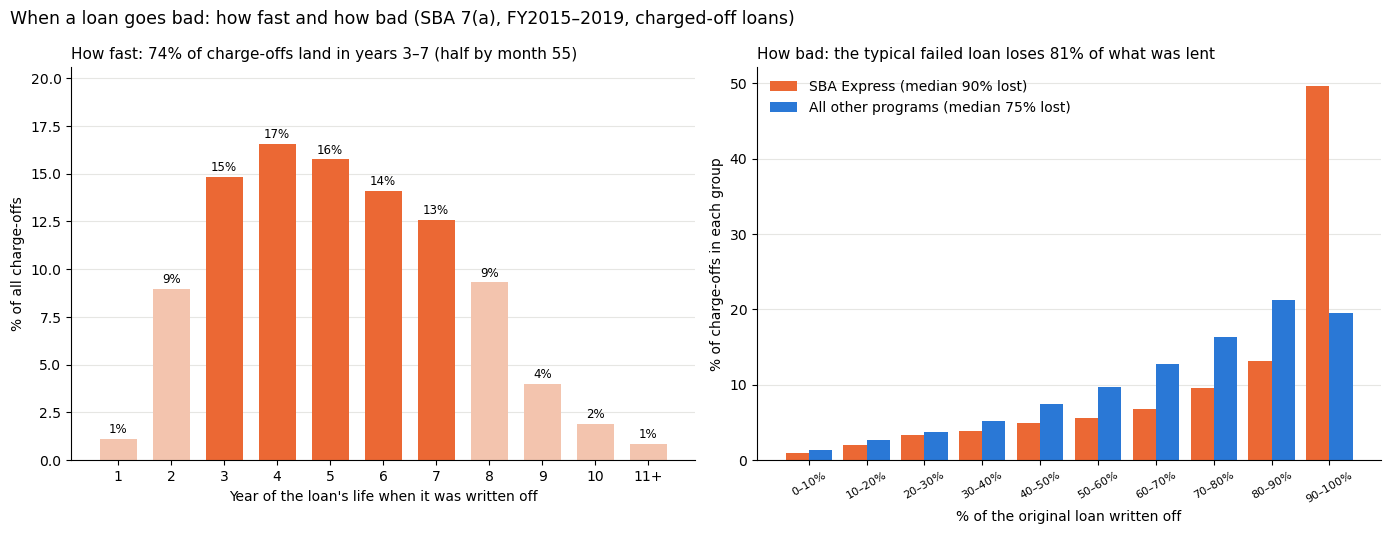

In [85]:
# Chart: how fast (which year of the loan's life it was written off) and how bad (% of the loan lost)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4))

# Left: share of charge-offs in each loan year; danger zone (years 3-7) highlighted. No second axis.
yr = co["loan_year"].value_counts(normalize=True).sort_index() * 100
danger = ["Year 3", "Year 4", "Year 5", "Year 6", "Year 7"]
colors = ["#eb6834" if y in danger else "#f3c4ae" for y in yr.index]
x = np.arange(len(yr))
ax1.bar(x, yr.values, color=colors, width=0.7)
for xi, v in zip(x, yr.values):
    ax1.text(xi, v + 0.3, f"{v:.0f}%", ha="center", fontsize=8.5)
ax1.set_xticks(x, [y.replace("Year ", "") for y in yr.index])
ax1.set_xlabel("Year of the loan's life when it was written off")
ax1.set_ylabel("% of all charge-offs")
ax1.set_ylim(0, yr.max() + 4)
ax1.set_title(f"How fast: {yr[danger].sum():.0f}% of charge-offs land in years 3–7 "
              f"(half by month {co['months_to_charge_off'].median():.0f})", loc="left", fontsize=11)

# Right: severity histogram, Express vs other programs (side by side, no overlap)
exp_mask = co["loan_program_group"].eq("SBA Express")
sev_bins = np.arange(0, 105, 10)
e_cnt, _ = np.histogram(co.loc[exp_mask, "severity_%"], bins=sev_bins)
o_cnt, _ = np.histogram(co.loc[~exp_mask, "severity_%"], bins=sev_bins)
e_pct, o_pct = e_cnt / e_cnt.sum() * 100, o_cnt / o_cnt.sum() * 100
xb = np.arange(len(e_cnt)); w = 0.4
ax2.bar(xb - w / 2, e_pct, w, color="#eb6834", label=f"SBA Express (median {co.loc[exp_mask, 'severity_%'].median():.0f}% lost)")
ax2.bar(xb + w / 2, o_pct, w, color="#2a78d6", label=f"All other programs (median {co.loc[~exp_mask, 'severity_%'].median():.0f}% lost)")
ax2.set_xticks(xb, [f"{a}–{a + 10}%" for a in sev_bins[:-1]], fontsize=8, rotation=30)
ax2.set_xlabel("% of the original loan written off")
ax2.set_ylabel("% of charge-offs in each group")
ax2.set_title(f"How bad: the typical failed loan loses {co['severity_%'].median():.0f}% of what was lent",
              loc="left", fontsize=11)
ax2.legend(frameon=False, loc="upper left")

for ax in (ax1, ax2):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color="#e6e6e3"); ax.set_axisbelow(True)
fig.suptitle("When a loan goes bad: how fast and how bad (SBA 7(a), FY2015–2019, charged-off loans)",
             x=0.01, ha="left", fontsize=12.5)
plt.tight_layout()
plt.show()


In [86]:
print("QUESTION 5: WHEN A LOAN GOES BAD, HOW BAD AND HOW FAST?")
print("=" * 70)

print("\n--- How fast ---")
print("Based on the data from 2015-2019, a loan that goes bad is typically written off about 4.5 years (55 months) after approval.")
print("Very few fail early: only 1% are written off in year 1 and 10% by month 24.")
print("The danger zone is years 3 to 7 (months 25-84): about 74% of all charge-offs happen in that window.")
print("The peak is years 4 and 5, when about 1 in 3 charge-offs happens (32%).")
print("The oldest loans (2015-2016), which we've watched the longest, show the same pattern: half written off by month 55.")

print("\n--- How bad ---")
print("When a loan goes bad, the typical loss is 81% of the original loan. Most of the money is gone.")
print("After the SBA guarantee pays its share, the bank itself typically loses about 22% of the loan, around $18,000 per failed loan.")

print("\n--- Which bad loans hurt the most ---")
print("SBA Express loans fail faster (about 51 months) and lose more (90% of the loan). The bank keeps 45% of the loan as its own loss, vs about 14% for PLP.")
print("Loans without collateral lose 90% when they fail, vs 76% for loans with collateral.")
print("Revolving credit lines are the worst: 95% of the loan is lost when they fail.")
print("Large loans ($1M+) fail later (about 77 months) and lose less (61%), but each failure costs the bank much more (about $237,000).")

print("\n--- Calendar check ---")
print("Charge-offs peaked in 2021-2022 (2,746 and 3,145 loans, the two highest years). COVID and the SBA's payment relief shifted some losses by a year or two.")

print("\n--- When to watch a loan most closely ---")
print("Set up closer reviews from year 2 through year 7 of every loan, with the most attention in years 3-5.")
print("Watch Express loans, loans without collateral and credit lines earlier and more closely: they fail sooner and lose more.")

print("\n--- What the data can't tell us ---")
print("The charge-off date is when the bank WROTE OFF the loan, usually months after the borrower stopped paying. Warning signs appear earlier than these dates.")
print("Loan amounts written off don't subtract money recovered later, so real losses may be a bit lower.")
print("762 loans show a write-off bigger than the original loan (e.g. credit lines, fees). Those were capped at 100%.")
print("Loans approved in 2019 have only about 7 years of history, so some later charge-offs are still to come.")

QUESTION 5: WHEN A LOAN GOES BAD, HOW BAD AND HOW FAST?

--- How fast ---
Based on the data from 2015-2019, a loan that goes bad is typically written off about 4.5 years (55 months) after approval.
Very few fail early: only 1% are written off in year 1 and 10% by month 24.
The danger zone is years 3 to 7 (months 25-84): about 74% of all charge-offs happen in that window.
The peak is years 4 and 5, when about 1 in 3 charge-offs happens (32%).
The oldest loans (2015-2016), which we've watched the longest, show the same pattern: half written off by month 55.

--- How bad ---
When a loan goes bad, the typical loss is 81% of the original loan. Most of the money is gone.
After the SBA guarantee pays its share, the bank itself typically loses about 22% of the loan, around $18,000 per failed loan.

--- Which bad loans hurt the most ---
SBA Express loans fail faster (about 51 months) and lose more (90% of the loan). The bank keeps 45% of the loan as its own loss, vs about 14% for PLP.
Loans wit